# TL;DR

This notebook examines whether a game studio can use observable game metadata to prioritise comparable-game review under limited analyst capacity. High engagement is defined as the top quartile of the supplied engagement proxy, and the main model uses leakage-controlled design, platform, franchise and metadata-text signals. The key evidence is not ROC-AUC alone, although the final model reaches 0.869 on the holdout set. In a fixed 600-game review queue, random screening identifies about 150 high-engagement games, the training-selected franchise-depth heuristic identifies 331, and the final ML model identifies 413. This demonstrates practical prioritisation value, but the model remains a human-in-the-loop screening tool because it still misses 337 high-engagement games and chronological testing shows temporal fragility.

**GitHub repository:** https://github.com/chrisnch/game-engagement-prioritisation-analytics  
**Colab fallback:** https://colab.research.google.com/github/chrisnch/game-engagement-prioritisation-analytics/blob/main/notebooks/final_notebook.ipynb

# Prioritising High-Engagement Game Review: An Evidence-Led Product Analytics Study

## Business context

This study is framed as a decision-support analysis for a hypothetical indie/AA game studio with limited product research, marketing and platform-porting capacity. The practical decision is which comparable games deserve scarce analyst attention, which observable market signals are reliable enough to support product positioning, and where human judgement remains indispensable.

## Committed business question

*Which observable factors are associated with top-quartile player engagement in this market snapshot, and how can a studio use those factors as screening signals without confusing prediction with causation?*

The decision problem is resource allocation. A small studio cannot maximise every design attribute, investigate every comparable title or port to every platform. The analysis therefore evaluates whether a model can rank comparable games for expert review. It does not estimate revenue, prove that any feature causes engagement or replace playtesting, audience research and producer judgement.

In [ ]:
# Submission-local / Colab environment check
from pathlib import Path as _Path
import os as _os
import subprocess as _subprocess
import sys as _sys

_REPO_URL = "https://github.com/chrisnch/game-engagement-prioritisation-analytics.git"
_COLAB_REPO_DIR = _Path("/content/game-engagement-prioritisation-analytics")
_DATA_RELATIVE = _Path("data") / "raw" / "Ultimate_Games_Dataset.csv"
_LOCAL_ROOTS = (_Path.cwd(), _Path.cwd() / "Part I", _Path.cwd().parent)
if not any((root / _DATA_RELATIVE).is_file() for root in _LOCAL_ROOTS):
    if "google.colab" in _sys.modules or _Path("/content").exists():
        if _COLAB_REPO_DIR.exists():
            _subprocess.run(["git", "-C", str(_COLAB_REPO_DIR), "pull", "--ff-only"], check=False)
        else:
            _subprocess.run(["git", "clone", "--depth", "1", _REPO_URL, str(_COLAB_REPO_DIR)], check=True)
        _os.chdir(_COLAB_REPO_DIR)
    else:
        raise FileNotFoundError(
            "Expected the submitted dataset at data/raw/Ultimate_Games_Dataset.csv. "
            "Run this notebook from the submitted project root (or its notebooks folder) "
            "and keep the data/raw directory in the ZIP."
        )
if not (_Path.cwd() / _DATA_RELATIVE).is_file():
    raise FileNotFoundError("Could not locate data/raw/Ultimate_Games_Dataset.csv after environment setup.")
print(f"Project structure detected at {_Path.cwd()}.")


---
## 0. Reproducible Environment

This notebook locates the submitted dataset through relative paths, records the analytical environment and fixes all declared random seeds. Generated tables and figures remain inside the project. Every transformation that learns from data is fitted within its training pipeline, preventing information from the holdout set from influencing preprocessing or model selection.


In [2]:
# Reproducibility and display helpers
from __future__ import annotations

import hashlib
import os
import sys
from pathlib import Path
import warnings

def find_part_i_dir() -> Path:
    data_relative = Path("data") / "raw" / "Ultimate_Games_Dataset.csv"
    local_candidates = (Path.cwd(), Path.cwd() / "Part I", Path.cwd().parent)
    for candidate in local_candidates:
        if (candidate / data_relative).is_file():
            return candidate
    raise FileNotFoundError(
        "Expected the submitted dataset at data/raw/Ultimate_Games_Dataset.csv. "
        "Keep that relative structure and run the notebook from the project root "
        "or the notebooks directory."
    )

# Resolve submission-relative paths once so every export is reproducible.
PART_I_DIR = find_part_i_dir()
RAW_DATA_PATH = PART_I_DIR / "data" / "raw" / "Ultimate_Games_Dataset.csv"
OUTPUT_DIR = PART_I_DIR / "outputs"
FIGURE_DIR = PART_I_DIR / "figures"
MPL_CACHE_DIR = PART_I_DIR / ".matplotlib_cache"
for directory in [OUTPUT_DIR, FIGURE_DIR, MPL_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
from IPython.display import display, HTML

import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score, make_scorer,
    precision_score, recall_score, roc_auc_score,
    PrecisionRecallDisplay, RocCurveDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ── Warm Editorial visual theme ───────────────────────────────────
# Anchored in Anthropic's terracotta-on-cream aesthetic.
# Design philosophy: one accent colour at 120%, everything else at 80%.
# Palette carries semantic roles so index positions are stable.
PALETTE = [
    "#CC785C",  # 0: terracotta        — primary accent
    "#B85D3D",  # 1: burnt terracotta  — contrast / negative signal
    "#4D9A8C",  # 2: muted teal        — positive / secondary
    "#C49B8A",  # 3: rose terracotta   — soft accent
    "#D4A843",  # 4: muted gold        — highlight
    "#5D8A82",  # 5: deeper teal       — secondary variant
    "#9C9C9C",  # 6: warm grey         — baseline / random
    "#EDE5DC",  # 7: warm cream        — below-threshold fill
]

# Terracotta is the only hue with multiple weights — it carries the
# brand signature.  Teal appears only when a second distinct hue is
# unavoidable (positive signal, grouped comparison).  Every other
# element stays in the warm-grey / cream neutral range.

sns.set_theme(style="whitegrid", context="notebook", palette=PALETTE)
plt.rcParams.update({
    # Font — intentional choice, not system default.
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "sans-serif"],
    "font.size": 10,
    "text.color": "#1D1D1F",          # near-black, not #000
    "axes.edgecolor": "#C7C7CC",      # subtle spine
    # Title / label / tick hierarchy.
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    # Grid — warm, barely there.
    "grid.alpha": 0.12,
    "grid.color": "#D9D0C5",           # warm grey, not cold #ccc
    # Spines — keep left + bottom only.
    "axes.spines.top": False,
    "axes.spines.right": False,
    # Resolution.
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "savefig.bbox": "tight",
    "savefig.facecolor": "#FAFAF8",    # barely-warm white
    "figure.facecolor": "white",        # notebook inline stays white
    # Legend.
    "legend.fontsize": 9,
    "legend.frameon": False,
    "legend.labelcolor": "#545458",     # muted secondary text
})

# Standardised figure sizes (inches) — three tiers for layout consistency.
FIG_SINGLE = (7.0, 5.0)
FIG_DUAL   = (12.0, 5.0)
FIG_WIDE   = (9.2, 5.0)

# Structural ink — near-black, not #000.  Used for reference lines,
# axes, and any element that would default to pure black.
INK = "#1D1D1F"

def save_multi(fig, *stems):
    """Save fig to FIGURE_DIR under every supplied stem (no extension)."""
    for stem in stems:
        fig.savefig(FIGURE_DIR / f"{stem}.png", bbox_inches="tight", facecolor="#FAFAF8", dpi=220)

import html as html_lib
from IPython.display import display, HTML

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

# Keep wide audit tables legible in both Jupyter and Classic HTML.
def display_wrapped_table(df, caption=None, hide_index=False, font_size="11px"):
    """Display a DataFrame with wrapped text so long business interpretation fields are not truncated."""
    table = df.copy()
    styled = (
        table.style
        .set_table_styles([
            {
                "selector": "table",
                "props": [
                    ("table-layout", "fixed"),
                    ("width", "100%"),
                    ("border-collapse", "collapse"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("white-space", "normal"),
                    ("word-wrap", "break-word"),
                    ("text-align", "left"),
                    ("vertical-align", "top"),
                    ("font-size", font_size),
                    ("padding", "8px"),
                    ("background-color", "#f2f2f2"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("white-space", "normal"),
                    ("word-wrap", "break-word"),
                    ("overflow-wrap", "break-word"),
                    ("text-align", "left"),
                    ("vertical-align", "top"),
                    ("font-size", font_size),
                    ("line-height", "1.35"),
                    ("padding", "8px"),
                ],
            },
        ])
        .set_properties(**{
            "white-space": "normal",
            "word-wrap": "break-word",
            "overflow-wrap": "break-word",
            "text-align": "left",
            "vertical-align": "top",
        })
    )
    if hide_index:
        styled = styled.hide(axis="index")
    if caption:
        styled = styled.set_caption(caption)
    display(styled)

def display_claim_evidence_cards(df):
    """Display the claim-evidence-action matrix as readable cards rather than a truncated wide table."""
    column_labels = {
        "evidence_en": "Evidence",
        "business_meaning_en": "Business meaning",
        "business_action_en": "Business action",
        "limitation_en": "Limitation",
    }
    cards = []
    for i, row in df.reset_index(drop=True).iterrows():
        claim = html_lib.escape(str(row.get("claim_en", "")))
        card_html = f"""
        <div style="
            border: 1px solid #d9d9d9;
            border-radius: 8px;
            padding: 14px 16px;
            margin: 12px 0;
            background-color: #fafafa;
            line-height: 1.45;
            font-size: 13px;
        ">
            <div style="font-weight: 700; font-size: 14px; margin-bottom: 8px;">
                Claim {i + 1}: {claim}
            </div>
        """
        for col, label in column_labels.items():
            value = html_lib.escape(str(row.get(col, "")))
            card_html += f"""
            <div style="margin-top: 6px;">
                <span style="font-weight: 700;">{label}:</span> {value}
            </div>
            """
        card_html += "</div>"
        cards.append(card_html)
    display(HTML("\n".join(cards)))

# Treat SHAP as an optional explanation layer, not a modelling dependency.
try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    shap = None
    SHAP_AVAILABLE = False
    print("SHAP unavailable:", exc)

versions = pd.DataFrame({
    "package": ["Python", "pandas", "numpy", "scipy", "scikit-learn", "matplotlib", "seaborn", "shap"],
    "version": [sys.version.split()[0], pd.__version__, np.__version__, scipy.__version__, sklearn.__version__, matplotlib.__version__, sns.__version__, getattr(shap, "__version__", "unavailable")],
})
display(versions)
print("Data source: data/raw/Ultimate_Games_Dataset.csv")
print("SHAP available:", SHAP_AVAILABLE)


,package,version
0,Python,3.12.13
1,pandas,3.0.3
2,numpy,2.4.6
3,scipy,1.17.1
4,scikit-learn,1.9.0
5,matplotlib,3.11.0
6,seaborn,0.13.2
7,shap,0.52.0


Data source: data/raw/Ultimate_Games_Dataset.csv
SHAP available: True


---
## 1. Business Problem and Executive Notebook Map

### Business Problem

An indie or mid-sized studio has limited development, marketing and platform-porting capacity. Its practical need is not a universal formula for success, but a defensible way to prioritise comparable-game research and challenge assumptions about design, franchise, release and distribution signals.

### Model boundary

This notebook treats the model as a constrained review-prioritisation tool, not as an automatic game-success predictor. The aim is to help a studio decide which comparable games deserve analyst attention first. The model output should therefore be interpreted as a ranking signal for human review, not as a causal rule, investment decision, or calibrated probability of commercial success.

### Executive Notebook Map

| Assignment requirement | Notebook section | Decision contribution |
|---|---|---|
| Business problem | Section 1 | Defines the stakeholder, constrained decision and model-use boundary |
| Dataset suitability | Section 2 | Audits provenance, dimensions and analytical roles |
| Data preprocessing | Section 3 | Separates observed quality problems from treatment decisions |
| Analysis | Sections 5–13 | Builds descriptive, statistical, predictive and explanatory evidence |
| Results and interpretation | Sections 9–13 | Quantifies discrimination, ranking value, uncertainty and fragility |
| Recommendations | Sections 14–18 | Converts evidence into bounded managerial actions |
| References and AI declaration | Section 19 | Documents evidence sources and transparent tool use |

### Quick Model Variable Guide

This compact guide covers every outcome and model-related variable used below. It is intentionally narrower than the full 43-column dataset dictionary.

| Variable | Reader-friendly name | Model role / availability |
|---|---|---|
| `engagement_score` | Composite engagement score | Target source only; excluded from all predictors |
| `high_engagement` | High-engagement class (`engagement_score` ≥ 4.25) | Derived binary outcome |
| `release_year` | Release year | Main stage-matched input |
| `platform_count` | Number of listed platforms | Main stage-matched input; removed in platform ablation |
| `is_multiplayer` | Multiplayer availability indicator | Main stage-matched input |
| `is_multi_platform` | Multi-platform availability indicator | Main stage-matched input; removed in platform ablation |
| `achievements_count` | Number of achievements | Main stage-matched input |
| `game_series_count` | Franchise / series depth | Main stage-matched input |
| `theme` | Game theme | Main stage-matched input |
| `art_style` | Art style | Main stage-matched input |
| `view_dimension` | View / dimensional perspective | Main stage-matched input |
| `game_mode` | Game mode | Main stage-matched input |
| `controls` | Control scheme | Main stage-matched input |
| `esrb_rating` | ESRB age rating | Main stage-matched input |
| `decade` | Release decade | Main stage-matched input |
| `design_text` | Combined design text: genres, tags and description | Engineered main stage-matched input |
| `platform_text` | Combined platform/distribution text: platforms and stores | Engineered main stage-matched input; removed in platform ablation |
| `user_rating` | User rating | Post-launch diagnostic only |
| `metacritic` | Metacritic review score | Post-launch diagnostic only |
| `ratings_count` | Number of user ratings | Post-launch diagnostic only |
| `reviews_count` | Number of reviews | Post-launch diagnostic only |
| `avg_playtime_hours` | Average playtime (hours) | Post-launch diagnostic only |

Platform ablation removes `platform_count`, `is_multi_platform` and `platform_text` while holding the remaining evidence and model family constant.

### Analytical Choice Rationale

- **Task fit:** A fixed top-quartile outcome creates a task-driven binary classification problem. Classification directly answers which games should enter a constrained review queue.
- **Model progression:** Logistic regression provides a transparent benchmark; a small decision tree tests simple non-linearity; random forest tests whether a controlled ensemble improves capacity-constrained ranking.
- **Generalisation:** Five-fold cross-validation selects the estimator using training data only. The 20% holdout is locked before modelling and used only for the pre-specified final evaluation suite.
- **Text evidence:** TF-IDF represents genre, tag, description and platform text, with vocabulary fitted independently inside each training fold.
- **Deliberate exclusions:** Clustering answers a different, unlabelled segmentation question. A neural network would add complexity without a demonstrated decision benefit for 15,000 observations.

### Model Use Policy

The output is a **review-queue priority score** for market benchmarking. It is suitable for ordering comparable titles for human investigation and supporting discussions about positioning and distribution. It is **not an automatic greenlight decision**, a causal estimate, a financial forecast or a substitute for user research, playtesting, cost analysis and producer judgement.


---
## AI Transparency Declaration

| Required item | Declaration |
|---|---|
| **WHY** | OpenAI ChatGPT was used for critical review, planning and interpretation advice. OpenAI Codex was used to reduce repetitive notebook-editing work, identify inconsistencies and improve structural clarity. |
| **WHAT** | AI was used for business-framing critique, code and test scaffolding, table and figure templates, contradiction checks and initial wording suggestions. |
| **WHICH AI** | OpenAI ChatGPT and OpenAI Codex. |
| **Directly used content** | Parts of the code scaffolding, validation tests, table/figure templates and explanatory drafts were used directly after being executed and checked against the saved numerical outputs. |
| **Student ownership** | The student selected the business problem, reviewed every analytical choice, checked the numerical evidence, accepted or rejected each recommendation, and can explain and reproduce the work. The student reviewed, executed and takes responsibility for the final submission. |


---
## 2. Dataset Source and Schema Audit

## Data Source and Provenance

The analysis uses Rudra Kumar Gupta's **Ultimate Games Dataset | 15K Games | 43 Features** from [Kaggle](https://www.kaggle.com/datasets/rudrakumargupta/ultimate-games-dataset-15k-games-43-features), accessed for this analysis on 11 June 2026. It is a secondary public dataset used for academic analysis. The submitted CSV is the sole analytical source; no external records are merged. The dataset licence should be verified before commercial reuse.

The 43 fields cover identity, release context, genre and design metadata, franchise depth, platform/store availability, ratings, reviews, playtime and a supplied `engagement_score`. However, the local artefacts do not document the target's formula, collection date or exposure window. I therefore treat `engagement_score` as an opaque market-engagement proxy rather than revenue, retention, playtime or a causal outcome.

The transposed preview below exposes all 43 fields for three example games. A complete field-level dictionary is validated against `df.columns` and exported to CSV, keeping the main notebook readable while preserving an auditable schema record.


In [3]:
# Schema contract and model-use roles
raw_df = pd.read_csv(RAW_DATA_PATH)
df = raw_df.copy()

print(f"Raw dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
assert df.shape == (15000, 43), "Expected the documented 15,000 x 43 Kaggle snapshot."

sample_preview = df.head(3).T
sample_preview.columns = [f"example_game_{i+1}" for i in range(sample_preview.shape[1])]
display_wrapped_table(sample_preview, caption="Sample source records (transposed for readability)")

# Separate planning-stage evidence from post-launch diagnostic variables.
column_groups = {
    "identity_and_links": ["serial_no", "game_id", "title", "url_slug", "cover_image_url", "official_website"],
    "release_and_design": [
        "release_date", "release_year", "decade", "all_genres", "theme", "art_style",
        "view_dimension", "game_mode", "is_multiplayer", "controls", "esrb_rating",
        "rating_tier", "metacritic_tier",
    ],
    "publisher_and_franchise": ["developers", "publishers", "achievements_count", "game_series_count"],
    "platform_and_store": ["all_platforms", "platform_count", "is_multi_platform", "available_stores"],
    "ratings_visibility_engagement": [
        "user_rating", "metacritic", "ratings_count", "reviews_count", "library_count",
        "avg_playtime_hours", "popularity_score", "engagement_score",
    ],
    "text_metadata": ["all_tags", "description_clean"],
    "status_leakage_risk": [
        "status_owned", "status_beaten", "status_playing", "status_dropped",
        "status_toplay", "status_yet",
    ],
}

mapped_columns = [column for columns in column_groups.values() for column in columns]
assert len(mapped_columns) == 43
assert len(mapped_columns) == len(set(mapped_columns)), "A source column was mapped more than once."
assert set(mapped_columns) == set(df.columns), f"Unmapped: {set(df.columns) - set(mapped_columns)}"

target_or_leakage = {
    "engagement_score", "popularity_score", "library_count", "status_owned", "status_beaten",
    "status_playing", "status_dropped", "status_toplay", "status_yet",
}
postlaunch_only = {"user_rating", "metacritic", "ratings_count", "reviews_count", "avg_playtime_hours"}
identifiers = {"serial_no", "game_id", "title", "url_slug", "cover_image_url", "official_website", "release_date", "developers", "publishers", "rating_tier", "metacritic_tier"}

schema_rows = []
for source_position, column in enumerate(df.columns):
    group = next(group for group, columns in column_groups.items() if column in columns)
    series = df[column]
    if column in target_or_leakage:
        analysis_role = "outcome/proxy or leakage risk"
        model_use = "excluded from all predictor sets"
    elif column in postlaunch_only:
        analysis_role = "post-launch monitoring signal"
        model_use = "post-launch diagnostic set only"
    elif column in identifiers:
        analysis_role = "identity/provenance or derived label"
        model_use = "not used as a direct predictor"
    else:
        analysis_role = "design/distribution screening candidate"
        model_use = "eligible for design/distribution screening model"

    na_count = int(series.isna().sum())
    is_text = pd.api.types.is_string_dtype(series.dtype) or series.dtype == object
    placeholder_count = int(series.astype("string").str.strip().eq("Not Specified").fillna(False).sum()) if is_text else 0
    if na_count:
        missing_policy = "numeric median imputation inside training pipeline + indicator"
    elif placeholder_count:
        missing_policy = "standardise 'Not Specified' to explicit 'Unknown' category"
    else:
        missing_policy = "no missing treatment required"
    example = series.dropna().astype(str).iloc[0] if series.notna().any() else ""
    schema_rows.append({
        "source_position": source_position,
        "column": column,
        "business_group": group,
        "dtype": str(series.dtype),
        "example": example,
        "analysis_role": analysis_role,
        "model_use": model_use,
        "missing_policy": missing_policy,
    })

column_group_table = pd.DataFrame(schema_rows)
# Export the schema audit as a reproducible evidence artefact.
column_group_table.to_csv(OUTPUT_DIR / "rebuild_column_groups.csv", index=False)
# Preserve the established filename while expanding it to the full audit schema.
column_group_table.to_csv(OUTPUT_DIR / "rebuild_variable_dictionary.csv", index=False)
column_group_table.to_csv(OUTPUT_DIR / "rebuild_data_dictionary.csv", index=False)


Raw dataset shape: 15,000 rows x 43 columns


,example_game_1,example_game_2,example_game_3
serial_no,1,2,3
game_id,3498,3328,4200
title,Grand Theft Auto V,The Witcher 3: Wild Hunt,Portal 2
release_date,2013-09-17,2015-05-18,2011-04-18
release_year,2013.000000,2015.000000,2011.000000
all_genres,Action,Action|RPG,Shooter|Puzzle
theme,Crime,Fantasy,Sci-Fi
art_style,Realistic,Realistic,Realistic
view_dimension,3D,3D,3D
game_mode,Single & Multiplayer,Singleplayer,Single & Multiplayer


### Evidence-led interpretation

**Analytical question.** Is the supplied dataset structurally broad and traceable enough to support the stated screening problem?

**Numerical evidence.** The source contains **15,000 games and 43 fields**. The schema assertions confirm that all **43 source fields are mapped exactly once**, with no duplicated mapping and exact equality to `df.columns`.

**Judgement.** The dataset is sufficiently broad for exploratory comparisons across design, franchise, platform, text and post-launch reception signals. Those roles are deliberately separated because a field observed after launch cannot support the same managerial claim as a planning-stage field.

**Alternative explanation.** Width is not the same as construct validity. Forty-three columns cannot compensate for missing collection timing, marketing spend, development budget or the undocumented target formula.

**Decision consequence.** The analysis can support market screening and prioritisation, but recommendations must remain associational and cannot promise commercial returns.


---
## 3. Data Quality and Preprocessing

This section separates **audit** from **treatment**. Real nulls, explicit placeholders, blanks, duplicates, range violations and cross-field inconsistencies are counted before any change is made. Placeholders are then standardised in a working copy, while valid long-tail observations are retained. Numeric imputation is deferred to fitted model pipelines so that holdout information cannot influence training transformations.


In [4]:
# Cleaning policy and data-quality checks
# Apply conservative, auditable cleaning before any target or split is created.
duplicate_game_id = int(raw_df["game_id"].duplicated().sum())
duplicate_title = int(raw_df["title"].astype("string").str.casefold().duplicated().sum())

missing_rows = []
for column in raw_df.columns:
    series = raw_df[column]
    is_text = pd.api.types.is_string_dtype(series.dtype) or series.dtype == object
    if is_text:
        stripped = series.astype("string").str.strip()
        not_specified = int(stripped.eq("Not Specified").fillna(False).sum())
        blank = int(stripped.eq("").fillna(False).sum())
    else:
        not_specified = blank = 0
    missing_rows.append({
        "column": column,
        "dtype": str(series.dtype),
        "na_count": int(series.isna().sum()),
        "na_pct": series.isna().mean() * 100,
        "not_specified_count": not_specified,
        "not_specified_pct": not_specified / len(raw_df) * 100,
        "blank_count": blank,
    })

missing_table = pd.DataFrame(missing_rows).sort_values(
    ["na_count", "not_specified_count"], ascending=False
).reset_index(drop=True)
display_wrapped_table(missing_table.query("na_count > 0 or not_specified_count > 0 or blank_count > 0"), caption="Columns requiring cleaning or missing-value handling", hide_index=True)
missing_table.to_csv(OUTPUT_DIR / "rebuild_missingness_summary.csv", index=False)

# Explicit treatment: standardise source placeholders without pretending they were observed values.
string_columns = [c for c in df.columns if pd.api.types.is_string_dtype(df[c].dtype) or df[c].dtype == object]
for column in string_columns:
    df[column] = df[column].astype("string").str.strip().replace({"Not Specified": "Unknown", "": "Unknown"})

df["release_date_parsed"] = pd.to_datetime(df["release_date"], errors="coerce")
platform_tokens = df["all_platforms"].str.split("|").str.len()
count_columns = [
    "ratings_count", "reviews_count", "library_count", "avg_playtime_hours",
    "achievements_count", "game_series_count", "status_owned", "status_beaten",
    "status_playing", "status_dropped", "status_toplay", "status_yet",
]

# Surface quality risks explicitly instead of silently dropping difficult rows.
quality_checks = pd.DataFrame([
    {"check": "duplicate_game_id", "value": duplicate_game_id, "expected": 0},
    {"check": "duplicate_title_casefold", "value": duplicate_title, "expected": 0},
    {"check": "invalid_release_date", "value": int(df["release_date_parsed"].isna().sum()), "expected": 0},
    {"check": "release_year_date_mismatch", "value": int((df["release_date_parsed"].dt.year != df["release_year"]).sum()), "expected": 0},
    {"check": "platform_count_token_mismatch", "value": int((platform_tokens != df["platform_count"]).sum()), "expected": 0},
    {"check": "is_multi_platform_mismatch", "value": int(((df["platform_count"] > 1).astype(int) != df["is_multi_platform"]).sum()), "expected": 0},
    {"check": "negative_count_values", "value": int((df[count_columns] < 0).sum().sum()), "expected": 0},
    {"check": "user_rating_outside_1_to_5", "value": int(((df["user_rating"].dropna() < 1) | (df["user_rating"].dropna() > 5)).sum()), "expected": 0},
    {"check": "metacritic_outside_0_to_100", "value": int(((df["metacritic"].dropna() < 0) | (df["metacritic"].dropna() > 100)).sum()), "expected": 0},
])
quality_checks["passed"] = quality_checks["value"] == quality_checks["expected"]
display_wrapped_table(quality_checks, caption="Data-quality checks", hide_index=True)
quality_checks.to_csv(OUTPUT_DIR / "rebuild_data_quality_audit.csv", index=False)
quality_checks.to_csv(OUTPUT_DIR / "data_quality_summary.csv", index=False)

numeric_audit_columns = [
    "release_year", "platform_count", "user_rating", "metacritic", "ratings_count",
    "reviews_count", "library_count", "avg_playtime_hours", "popularity_score", "engagement_score",
]
outlier_rows = []
for column in numeric_audit_columns:
    s = pd.to_numeric(df[column], errors="coerce")
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)
    outlier_rows.append({
        "column": column, "missing": int(s.isna().sum()), "min": s.min(), "q1": q1,
        "median": s.median(), "q3": q3, "max": s.max(),
        "iqr_outlier_count": int(mask.sum()), "iqr_outlier_pct": mask.mean() * 100,
        "decision": "retain; validate ranges and use robust summaries/log views",
    })
# Retain plausible extreme values and report them for sensitivity review.
outlier_audit = pd.DataFrame(outlier_rows)
display_wrapped_table(outlier_audit, caption="Numeric range and outlier audit", hide_index=True)
display_wrapped_table(df.nlargest(10, "engagement_score")[["title", "engagement_score", "reviews_count", "library_count", "avg_playtime_hours"]], caption="Top engagement-score records for proxy audit", hide_index=True)
outlier_audit.to_csv(OUTPUT_DIR / "rebuild_outlier_audit.csv", index=False)

preprocessing_log = pd.DataFrame([
    {"stage": "raw CSV loaded", "rows": len(raw_df), "columns": raw_df.shape[1], "action": "immutable source retained"},
    {"stage": "duplicate audit", "rows": len(df), "columns": raw_df.shape[1], "action": f"0 duplicate game_id; {duplicate_title} duplicate casefold title"},
    {"stage": "placeholder standardisation", "rows": len(df), "columns": raw_df.shape[1], "action": "Not Specified/blank -> explicit Unknown in working copy"},
    {"stage": "date and cross-field validation", "rows": len(df), "columns": raw_df.shape[1], "action": "parsed date plus platform/year/count consistency checks"},
    {"stage": "outlier decision", "rows": len(df), "columns": raw_df.shape[1], "action": "retained valid long-tail observations; no row deletion"},
])
display_wrapped_table(preprocessing_log, caption="Preprocessing log", hide_index=True)
preprocessing_log.to_csv(OUTPUT_DIR / "rebuild_preprocessing_log.csv", index=False)

assert quality_checks["passed"].all()
assert len(df) == 15000


column,dtype,na_count,na_pct,not_specified_count,not_specified_pct,blank_count
metacritic,float64,886,5.906667,0,0.000000,0
user_rating,float64,387,2.580000,0,0.000000,0
game_mode,str,0,0.000000,2006,13.373333,0
available_stores,str,0,0.000000,1528,10.186667,0
publishers,str,0,0.000000,1499,9.993333,0
developers,str,0,0.000000,1335,8.900000,0
all_tags,str,0,0.000000,1191,7.940000,0
theme,str,0,0.000000,1063,7.086667,0
art_style,str,0,0.000000,1063,7.086667,0
view_dimension,str,0,0.000000,1063,7.086667,0


check,value,expected,passed
duplicate_game_id,0,0,True
duplicate_title_casefold,0,0,True
invalid_release_date,0,0,True
release_year_date_mismatch,0,0,True
platform_count_token_mismatch,0,0,True
is_multi_platform_mismatch,0,0,True
negative_count_values,0,0,True
user_rating_outside_1_to_5,0,0,True
metacritic_outside_0_to_100,0,0,True


column,missing,min,q1,median,q3,max,iqr_outlier_count,iqr_outlier_pct,decision
release_year,0,1979.000000,2014.000000,2016.000000,2020.000000,2026.000000,1000,6.666667,retain; validate ranges and use robust summaries/log views
platform_count,0,1.000000,1.000000,2.000000,3.000000,22.000000,606,4.040000,retain; validate ranges and use robust summaries/log views
user_rating,387,1.000000,2.810000,3.430000,3.800000,5.000000,41,0.273333,retain; validate ranges and use robust summaries/log views
metacritic,886,23.000000,66.000000,70.000000,75.100000,99.000000,510,3.400000,retain; validate ranges and use robust summaries/log views
ratings_count,0,0.000000,2.000000,17.000000,68.000000,7153.000000,1892,12.613333,retain; validate ranges and use robust summaries/log views
reviews_count,0,0.000000,1.000000,15.000000,68.000000,7268.000000,1900,12.666667,retain; validate ranges and use robust summaries/log views
library_count,0,0.000000,11.000000,281.000000,743.000000,22126.000000,1487,9.913333,retain; validate ranges and use robust summaries/log views
avg_playtime_hours,0,0.000000,1.000000,3.000000,4.000000,367.000000,812,5.413333,retain; validate ranges and use robust summaries/log views
popularity_score,0,1.610000,20.230000,26.500000,30.800000,96.280000,1329,8.860000,retain; validate ranges and use robust summaries/log views
engagement_score,0,0.000000,0.450000,1.825000,4.250000,41.930000,1633,10.886667,retain; validate ranges and use robust summaries/log views


title,engagement_score,reviews_count,library_count,avg_playtime_hours
Wet steps,41.930000,5.000000,5.000000,3.000000
Pokémon Platinum,41.120000,267.000000,620.000000,114.000000
Metal Gear Solid: Peace Walker,39.170000,198.000000,510.000000,211.000000
"Pokémon X, Y",38.720000,403.000000,903.000000,84.000000
Pokémon GO,38.530000,335.000000,603.000000,367.000000
Dishonored: The Knife of Dunwall,38.290000,173.000000,296.000000,3.000000
The Last of Us: Left Behind,37.990000,564.000000,958.000000,3.000000
Cats Hidden in Jingle Jam,37.940000,6.000000,7.000000,2.000000
The Walking Dead: 400 Days,37.700000,170.000000,298.000000,3.000000
Dishonored: The Brigmore Witches,36.820000,173.000000,297.000000,3.000000


stage,rows,columns,action
raw CSV loaded,15000,43,immutable source retained
duplicate audit,15000,43,0 duplicate game_id; 0 duplicate casefold title
placeholder standardisation,15000,43,Not Specified/blank -> explicit Unknown in working copy
date and cross-field validation,15000,43,parsed date plus platform/year/count consistency checks
outlier decision,15000,43,retained valid long-tail observations; no row deletion


In [5]:
met_missing = missing_table.set_index("column").loc["metacritic"]
user_missing = missing_table.set_index("column").loc["user_rating"]
review_missing = missing_table.set_index("column").loc["reviews_count"]
mode_unknown = missing_table.set_index("column").loc["game_mode", "not_specified_count"]
stores_unknown = missing_table.set_index("column").loc["available_stores", "not_specified_count"]

### Evidence-led interpretation

**Analytical question.** Which quality problems require treatment, and would deletion remove meaningful long-tail games?

**Numerical evidence.** `metacritic` has **886 missing values (5.91%)** and `user_rating` has **387 (2.58%)**. Explicit `Not Specified` values are more common: **2,006 (13.37%)** for `game_mode`, **1,528 (10.19%)** for `available_stores` and **1,499 (9.99%)** for `publishers`. The audit finds **zero** duplicate IDs, duplicate case-folded titles, invalid release dates, year/date mismatches, platform-count mismatches, negative count values or rating-range violations. IQR rules flag **1,633 engagement observations (10.89%)** and **1,900 review counts (12.67%)**, yet all **15,000 rows** survive every processing stage.

**Judgement.** The dominant issue is incomplete documentation rather than corrupted records. Explicit `Unknown` categories preserve that uncertainty, while median imputation and missingness indicators belong inside the fitted pipelines.

**Alternative explanation.** Missing critic coverage may itself signal low visibility, but this cross-sectional snapshot cannot distinguish MCAR, MAR and MNAR mechanisms. Likewise, IQR flags identify rarity, not error; the maximum engagement value of 41.93 may represent a legitimate long-tail title.

**Decision consequence.** Retain every game, expose missingness to the model and avoid trimming commercially important hits merely because their values are extreme.


---
## 4. Outcome Definition

The business task is screening rather than estimating the exact engagement score. I therefore define `high_engagement` as `engagement_score >= 4.25`, the fixed upper-quartile benchmark in this snapshot. The threshold is frozen before modelling for reproducibility, and the 80/20 stratified split preserves the class share while leaving 3,000 games untouched for final evaluation.

Right-skewness motivates robust description, but it does not by itself invalidate regression. Classification is selected because the decision is whether a title enters a priority group, not because the distribution mechanically dictates a modelling family.

#### Target interpretation caution

The high-engagement label is a practical screening target derived from the supplied engagement proxy. It should not be interpreted as revenue, profit, retention, sales volume, or overall commercial success. This matters because the project evaluates whether the model can prioritise games for further review, rather than whether it can determine which games should be developed, funded, or launched.

#### Validation interpretation

The random stratified holdout evaluates whether the model can rank unseen games within the same market snapshot. This is appropriate for the notebook’s main screening use case, where a studio reviews comparable games drawn from a similar market universe. However, it does not guarantee future launch forecasting performance. For that reason, the chronological sensitivity test is treated as a separate robustness check that highlights temporal drift and the need to refresh the model before live deployment.


In [6]:
# Target construction and locked split
ENGAGEMENT_THRESHOLD = 4.25
df["high_engagement"] = (df["engagement_score"] >= ENGAGEMENT_THRESHOLD).astype(int)
df["platform_count_group"] = pd.cut(
    df["platform_count"], bins=[0, 1, 2, 3, 5, np.inf],
    labels=["1 platform", "2 platforms", "3 platforms", "4-5 platforms", "6+ platforms"],
    include_lowest=True,
)
# Build text features only from fields available to the stated decision stage.
df["design_text"] = df[["all_genres", "all_tags", "description_clean"]].fillna("").astype(str).agg(" ".join, axis=1)
df["platform_text"] = df[["all_platforms", "available_stores"]].fillna("").astype(str).agg(" ".join, axis=1)

# Lock a stratified holdout before model comparison to protect the final estimate.
train_index, holdout_index = train_test_split(
    df.index, test_size=0.20, stratify=df["high_engagement"], random_state=RANDOM_STATE
)
train_index = pd.Index(train_index)
holdout_index = pd.Index(holdout_index)
assert len(train_index.intersection(holdout_index)) == 0

target_summary = pd.DataFrame([
    {"metric": "fixed_threshold", "full_snapshot": ENGAGEMENT_THRESHOLD, "training": ENGAGEMENT_THRESHOLD, "holdout": ENGAGEMENT_THRESHOLD},
    {"metric": "rows", "full_snapshot": len(df), "training": len(train_index), "holdout": len(holdout_index)},
    {"metric": "positive_rate", "full_snapshot": df["high_engagement"].mean(), "training": df.loc[train_index, "high_engagement"].mean(), "holdout": df.loc[holdout_index, "high_engagement"].mean()},
])
display(target_summary)
target_summary.to_csv(OUTPUT_DIR / "rebuild_target_definition.csv", index=False)


,metric,full_snapshot,training,holdout
0,fixed_threshold,4.250000,4.250000,4.25
1,rows,15000.000000,12000.000000,3000.00
2,positive_rate,0.250133,0.250167,0.25


,engagement_score
count,15000.000000
mean,3.813943
std,5.679271
min,0.000000
10%,0.160000
25%,0.450000
50%,1.825000
75%,4.250000
90%,10.310000
95%,16.870000


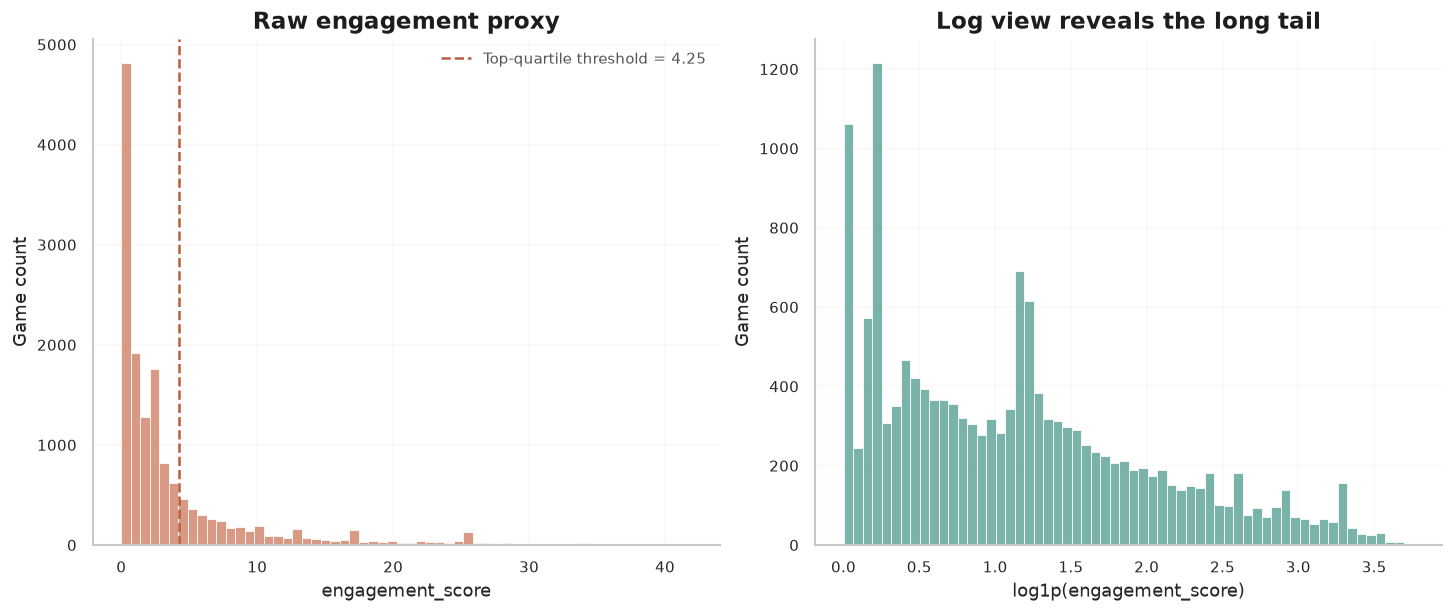

In [7]:
# Target distribution and threshold visualisation
engagement = df["engagement_score"]
engagement_summary = engagement.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("engagement_score")
display(engagement_summary)
engagement_summary.to_csv(OUTPUT_DIR / "rebuild_engagement_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=FIG_DUAL, constrained_layout=True)
sns.histplot(data=df, x="engagement_score", bins=60, ax=axes[0], color=PALETTE[0])
axes[0].axvline(ENGAGEMENT_THRESHOLD, color=PALETTE[1], linestyle="--", label="Top-quartile threshold = 4.25")
axes[0].set(title="Raw engagement proxy", xlabel="engagement_score", ylabel="Game count")
axes[0].legend()
sns.histplot(x=np.log1p(df["engagement_score"]), bins=60, ax=axes[1], color=PALETTE[2])
axes[1].set(title="Log view reveals the long tail", xlabel="log1p(engagement_score)", ylabel="Game count")
save_multi(fig, "rebuild_engagement_distribution", "target_distribution")
plt.show()

### Evidence-led interpretation

**Analytical question.** Does the supplied engagement proxy support a stable, decision-relevant screening threshold?

**Numerical evidence.** Across **15,000 games**, mean engagement is **3.814**, while the median is only **1.825**. The 75th percentile is **4.25**, the 90th is **10.31**, the 99th is **26.57**, and the maximum is **41.93**. This gap between the mean and median, together with the long upper tail, confirms substantial right-skew. The fixed threshold produces **3,752 positives (25.01%)** overall, with virtually identical prevalence in training (25.02%) and holdout (25.00%).

**Judgement.** The 4.25 cutoff creates a reproducible top-quartile screening task and stratification has preserved its prevalence. The analytical justification is alignment with a constrained review decision, not a claim that 4.25 is a naturally occurring boundary.

**Alternative explanation.** A different studio could rationally define opportunity more narrowly or broadly. The target's undocumented construction also means that stable class prevalence does not establish construct validity.

**Decision consequence.** Keep 4.25 as the pre-committed primary definition and treat nearby top-20%, top-25% and top-30% definitions only as sensitivity checks.


---
## 5. Descriptive Evidence

The following summaries describe the complete supplied market snapshot; they do not fit model parameters or estimate causal effects. Multi-label genre rows overlap because one game can carry several genres. Genre, theme and decade comparisons are therefore used to identify potentially useful comparable-game segments, not to test independent treatment groups.


,all_genres,games,median_engagement,mean_engagement,median_platform_count,median_reviews
0,Shooter,908,4.39,6.630639,3.0,119.0
1,Fighting,223,3.81,6.585919,3.0,72.0
2,Platformer,491,3.72,7.108208,4.0,95.0
3,Family,154,3.66,4.848766,5.0,68.0
4,Arcade,695,2.63,5.623612,4.0,62.0
5,Puzzle,753,2.38,4.061222,4.0,39.0
6,Adventure,6383,2.11,3.946444,2.0,12.0
7,Action,5649,2.10,4.067777,3.0,45.0
8,Racing,511,1.76,3.534638,3.0,40.0
9,RPG,3528,1.69,3.698262,2.0,15.0


,theme,games,median_engagement,mean_engagement,median_platform_count,median_reviews
0,Crime,540,3.265,5.347759,3.0,51.0
1,Sports,211,2.730,5.864787,3.0,70.0
2,Mythology,115,2.490,4.767217,3.0,38.0
3,Adventure,477,2.450,5.951887,3.0,41.0
4,Horror,2412,2.275,4.314996,2.0,28.0
5,Post-Apocalyptic,221,2.210,3.653348,3.0,49.0
6,Comedy,682,2.130,4.267815,2.0,2.0
7,Historical,650,2.110,3.863200,2.0,34.0
8,Sci-Fi,3160,1.925,3.634560,3.0,34.0
9,General,2960,1.880,3.997544,1.0,2.0


,decade,games,median_engagement,median_reviews,median_platform_count
0,1970s,2,0.220,41.0,6.5
1,1980s,69,10.700,78.0,5.0
2,1990s,468,3.275,65.5,3.0
3,2000s,1437,3.790,73.0,2.0
4,2010s,8571,1.680,21.0,3.0
5,2020s,4453,1.420,1.0,1.0


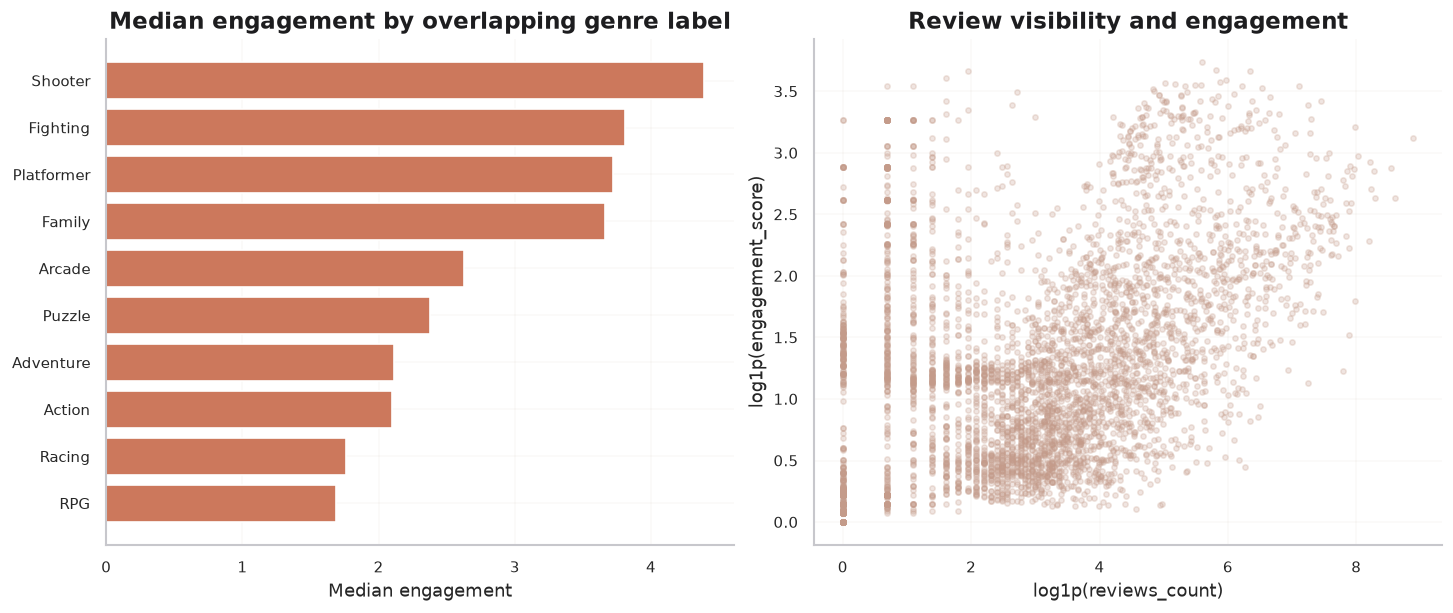

In [8]:
# Genre and design summaries for descriptive comparison
def explode_pipe_column(data: pd.DataFrame, column: str) -> pd.DataFrame:
    return (
        data[["game_id", column, "engagement_score", "platform_count", "reviews_count"]]
        .assign(**{column: data[column].fillna("Unknown").astype(str).str.split("|")})
        .explode(column)
        .assign(**{column: lambda x: x[column].str.strip()})
    )

genre_long = explode_pipe_column(df, "all_genres")
genre_summary = (
    genre_long.groupby("all_genres")
    .agg(games=("game_id", "nunique"), median_engagement=("engagement_score", "median"), mean_engagement=("engagement_score", "mean"), median_platform_count=("platform_count", "median"), median_reviews=("reviews_count", "median"))
    .query("games >= 100 and all_genres != 'Unknown'")
    .sort_values("median_engagement", ascending=False).reset_index()
)
theme_summary = (
    df.groupby("theme").agg(games=("game_id", "size"), median_engagement=("engagement_score", "median"), mean_engagement=("engagement_score", "mean"), median_platform_count=("platform_count", "median"), median_reviews=("reviews_count", "median"))
    .query("games >= 100 and theme != 'Unknown'").sort_values("median_engagement", ascending=False).reset_index()
)
decade_summary = df.groupby("decade").agg(games=("game_id", "size"), median_engagement=("engagement_score", "median"), median_reviews=("reviews_count", "median"), median_platform_count=("platform_count", "median")).reset_index()

display(genre_summary.head(15)); display(theme_summary.head(12)); display(decade_summary)
genre_summary.to_csv(OUTPUT_DIR / "rebuild_genre_summary.csv", index=False)
theme_summary.to_csv(OUTPUT_DIR / "rebuild_theme_summary.csv", index=False)
decade_summary.to_csv(OUTPUT_DIR / "rebuild_decade_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=FIG_DUAL, constrained_layout=True)
top_genres = genre_summary.head(10).sort_values("median_engagement")
axes[0].barh(top_genres["all_genres"], top_genres["median_engagement"], color=PALETTE[0])
axes[0].set(title="Median engagement by overlapping genre label", xlabel="Median engagement", ylabel="")
sample_scatter = df.sample(5000, random_state=RANDOM_STATE)
axes[1].scatter(np.log1p(sample_scatter["reviews_count"]), np.log1p(sample_scatter["engagement_score"]), s=10, alpha=.25, color=PALETTE[3], rasterized=True)
axes[1].set(title="Review visibility and engagement", xlabel="log1p(reviews_count)", ylabel="log1p(engagement_score)")
save_multi(fig, "rebuild_market_overview", "eda_key_differences")
plt.show()

shooter = genre_summary.set_index("all_genres").loc["Shooter"]
rpg = genre_summary.set_index("all_genres").loc["RPG"]

### Evidence-led interpretation

**Analytical question.** Which market segments show the largest descriptive engagement differences, and are those differences credible as design prescriptions?

**Numerical evidence.** Shooter games have median engagement **4.39 (n=908)**, compared with **1.16** for Strategy (**n=2,540**) and Casual (**n=4,597**) labels. Crime-themed games reach **3.27 (n=540)** versus **1.86 (n=2,509)** for Fantasy. Decade patterns are even more exposed to sampling: the 1980s median is **10.70** but represents only **69 games**, whereas the 2020s median is **1.42** across **4,453 games**.

**Judgement.** The tables identify segments worth investigating, but the strongest raw differences coincide with different platform breadth, review visibility, franchise maturity and exposure time. The small 1980s sample is especially unsuitable for a broad historical conclusion.

**Alternative explanation.** Genre overlap violates independent-group interpretation, and newer titles have had less time to accumulate reviews, ports and the opaque engagement proxy. A Shooter-versus-Strategy contrast may therefore reflect market history and visibility as much as design.

**Decision consequence.** Use high-engagement segments to select comparable titles and formulate research questions; do not copy a genre or theme on the assumption that its label causes engagement.


,platform_count_group,games,median_engagement,mean_engagement,median_reviews,median_user_rating,median_metacritic
0,1 platform,5995,0.910,2.941688,3.0,3.40,68.8
1,2 platforms,2268,1.775,3.971984,14.0,3.34,70.0
2,3 platforms,3188,1.835,3.865317,17.0,3.35,70.1
3,4-5 platforms,2271,2.710,4.604866,56.0,3.47,73.0
4,6+ platforms,1278,3.995,6.091541,112.5,3.64,75.0


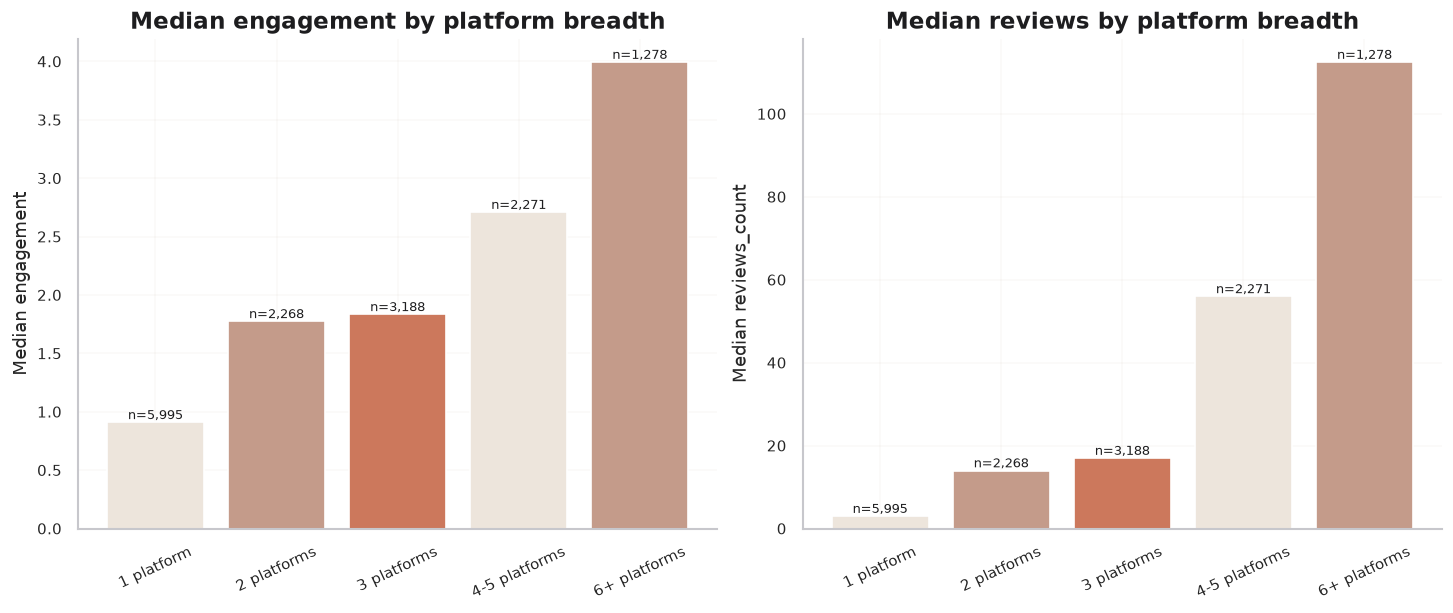

In [9]:
# Platform breadth summaries for non-causal benchmarking
platform_summary = (
    df.groupby("platform_count_group", observed=False)
    .agg(games=("game_id", "size"), median_engagement=("engagement_score", "median"), mean_engagement=("engagement_score", "mean"), median_reviews=("reviews_count", "median"), median_user_rating=("user_rating", "median"), median_metacritic=("metacritic", "median"))
    .reset_index()
)
display(platform_summary)
platform_summary.to_csv(OUTPUT_DIR / "rebuild_platform_strategy_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=FIG_DUAL, constrained_layout=True)
colors = sns.color_palette(
    [PALETTE[7], PALETTE[3], PALETTE[0]],
    n_colors=len(platform_summary),
)
axes[0].bar(platform_summary["platform_count_group"].astype(str), platform_summary["median_engagement"], color=colors)
axes[1].bar(platform_summary["platform_count_group"].astype(str), platform_summary["median_reviews"], color=colors)
for ax, values in zip(axes, [platform_summary["median_engagement"], platform_summary["median_reviews"]]):
    for i, (value, n) in enumerate(zip(values, platform_summary["games"])):
        ax.text(i, value, f"n={n:,}", ha="center", va="bottom", fontsize=8)
    ax.tick_params(axis="x", rotation=25)
axes[0].set(title="Median engagement by platform breadth", xlabel="", ylabel="Median engagement")
axes[1].set(title="Median reviews by platform breadth", xlabel="", ylabel="Median reviews_count")
save_multi(fig, "rebuild_platform_deep_dive")
plt.show()

one_platform = platform_summary.iloc[0]
six_plus = platform_summary.iloc[-1]
platform_delta = six_plus.median_engagement - one_platform.median_engagement
platform_review_rho = df[["platform_count", "reviews_count"]].corr(method="spearman").iloc[0, 1]

### Evidence-led interpretation

**Analytical question.** Is platform breadth informative enough to guide distribution planning?

**Numerical evidence.** Median engagement rises from **0.91 among 5,995 one-platform games** to **4.00 among 1,278 games on six or more platforms**. Median review count simultaneously rises from **3.0 to 112.5**, and platform count has a Spearman correlation of approximately **0.442** with review count.

**Judgement.** Platform breadth is a strong descriptive marker of visibility and market reach. The joint increase in engagement and reviews makes it useful for identifying established or well-resourced comparables.

**Alternative explanation.** The direction of influence is unresolved. Successful games may receive later ports, while publisher reach, development budget and franchise strength can increase both platform coverage and engagement. Current platform fields also do not identify original launch platforms.

**Decision consequence.** Include platform breadth in market screening, but evaluate an actual port using audience fit, delivery cost and timing evidence rather than assuming that each additional platform creates engagement.


---
## 6. Statistical Comparisons

Numeric distributions are skewed, so the analysis compares high- and non-high-engagement groups using two-sided Mann-Whitney tests and rank-biserial effect sizes. Eight numeric comparisons receive Holm correction. A chi-square test and Cramer's V assess the association between platform breadth groups and the binary outcome. With 15,000 observations, practical magnitude is more informative than whether a p-value merely crosses 0.05.


,variable,high_median,non_high_median,median_difference_raw_units,mann_whitney_u,p_value_raw,rank_biserial_effect,n_high_non_missing,n_non_high_non_missing,p_value_holm,p_value_report
0,user_rating,3.83,3.23,0.60,31999403.5,0.000000e+00,0.570505,3752,10861,0.000000e+00,p < .001
1,reviews_count,92.00,10.00,82.00,31879391.5,0.000000e+00,0.510782,3752,11248,0.000000e+00,p < .001
2,metacritic,75.85,68.90,6.95,28753717.5,0.000000e+00,0.479168,3752,10362,0.000000e+00,p < .001
3,ratings_count,91.00,12.00,79.00,30855727.0,0.000000e+00,0.462270,3752,11248,0.000000e+00,p < .001
4,avg_playtime_hours,3.00,2.00,1.00,29574429.0,1.222500e-309,0.401549,3752,11248,4.890000e-309,p < .001
5,platform_count,3.00,2.00,1.00,26691504.0,9.932238e-142,0.264925,3752,11248,2.979671e-141,p < .001
6,library_count,401.00,258.00,143.00,26053357.5,3.803910e-103,0.234683,3752,11248,7.607820e-103,p < .001
7,release_year,2016.00,2016.00,0.00,19556359.5,1.580433e-11,-0.073213,3752,11248,1.580433e-11,p < .001


,test,chi_square,p_value,dof,cramers_v,min_expected_count
0,platform_count_group_vs_high_engagement,724.400418,1.813819e-155,4,0.219758,319.6704


,engagement_score,platform_count,reviews_count,ratings_count,library_count,avg_playtime_hours,user_rating,metacritic,release_year
engagement_score,1.000,0.277,0.585,0.465,0.418,0.459,0.336,0.366,-0.131
platform_count,0.277,1.000,0.442,0.464,0.389,0.174,0.118,0.220,-0.188
reviews_count,0.585,0.442,1.000,0.940,0.917,0.315,0.120,0.412,-0.438
ratings_count,0.465,0.464,0.940,1.000,0.834,0.188,0.146,0.425,-0.491
library_count,0.418,0.389,0.917,0.834,1.000,0.281,-0.042,0.302,-0.426
avg_playtime_hours,0.459,0.174,0.315,0.188,0.281,1.000,0.195,0.157,0.073
user_rating,0.336,0.118,0.120,0.146,-0.042,0.195,1.000,0.696,0.149
metacritic,0.366,0.220,0.412,0.425,0.302,0.157,0.696,1.000,0.001
release_year,-0.131,-0.188,-0.438,-0.491,-0.426,0.073,0.149,0.001,1.000


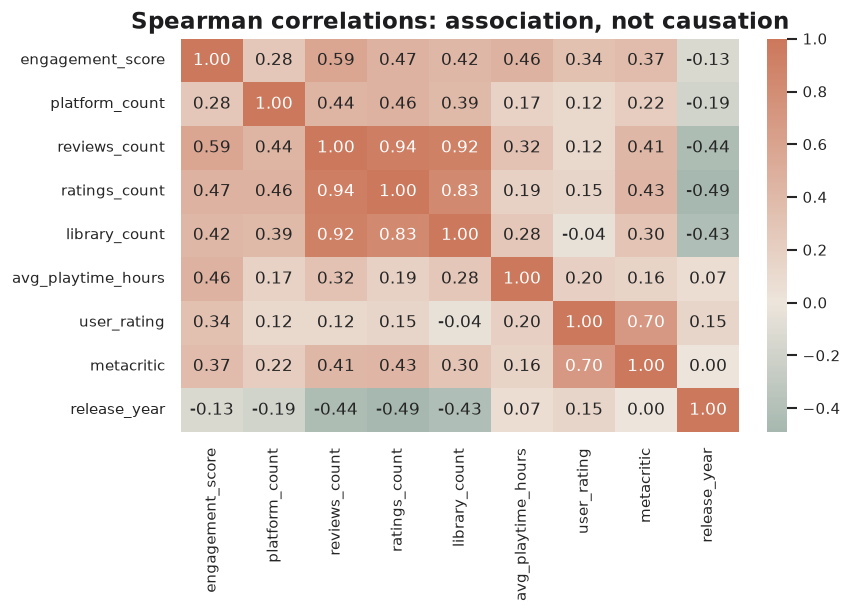

In [10]:
# Statistical comparison tests and effect-size calculations
def rank_biserial_from_u(u_stat: float, n_high: int, n_low: int) -> float:
    return (2 * u_stat / (n_high * n_low)) - 1

def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running = 0.0
    n = len(p_values)
    for rank, index in enumerate(order):
        running = max(running, (n - rank) * p_values[index])
        adjusted[index] = min(1.0, running)
    return adjusted

comparison_vars = ["platform_count", "reviews_count", "ratings_count", "library_count", "avg_playtime_hours", "user_rating", "metacritic", "release_year"]
comparison_rows = []
for column in comparison_vars:
    high = pd.to_numeric(df.loc[df["high_engagement"] == 1, column], errors="coerce").dropna()
    low = pd.to_numeric(df.loc[df["high_engagement"] == 0, column], errors="coerce").dropna()
    u_stat, p_value = stats.mannwhitneyu(high, low, alternative="two-sided")
    comparison_rows.append({
        "variable": column, "high_median": high.median(), "non_high_median": low.median(),
        "median_difference_raw_units": high.median() - low.median(), "mann_whitney_u": u_stat,
        "p_value_raw": p_value, "rank_biserial_effect": rank_biserial_from_u(u_stat, len(high), len(low)),
        "n_high_non_missing": len(high), "n_non_high_non_missing": len(low),
    })
group_comparison = pd.DataFrame(comparison_rows)
group_comparison["p_value_holm"] = holm_adjust(group_comparison["p_value_raw"])
group_comparison["p_value_report"] = group_comparison["p_value_holm"].map(lambda p: "p < .001" if p < .001 else f"p = {p:.3f}")
group_comparison = group_comparison.sort_values("rank_biserial_effect", ascending=False).reset_index(drop=True)
display(group_comparison)
group_comparison.to_csv(OUTPUT_DIR / "rebuild_group_comparison_tests.csv", index=False)

contingency = pd.crosstab(df["platform_count_group"], df["high_engagement"])
chi2, chi_p, chi_dof, expected = stats.chi2_contingency(contingency)
cramers_v = np.sqrt(chi2 / (contingency.to_numpy().sum() * (min(contingency.shape) - 1)))
platform_chi = pd.DataFrame([{"test": "platform_count_group_vs_high_engagement", "chi_square": chi2, "p_value": chi_p, "dof": chi_dof, "cramers_v": cramers_v, "min_expected_count": expected.min()}])
display(platform_chi)
platform_chi.to_csv(OUTPUT_DIR / "rebuild_platform_chi_square.csv", index=False)

corr_columns = ["engagement_score", "platform_count", "reviews_count", "ratings_count", "library_count", "avg_playtime_hours", "user_rating", "metacritic", "release_year"]
spearman_corr = df[corr_columns].corr(method="spearman")
display(spearman_corr.round(3))
spearman_corr.to_csv(OUTPUT_DIR / "rebuild_spearman_correlations.csv")
fig, ax = plt.subplots(figsize=FIG_SINGLE, constrained_layout=True)
sns.heatmap(spearman_corr, annot=True, fmt=".2f",
            cmap=matplotlib.colors.LinearSegmentedColormap.from_list(
                "warm_diverging", [PALETTE[5], PALETTE[7], PALETTE[0]]),
            center=0, ax=ax)
ax.set_title("Spearman correlations: association, not causation")
save_multi(fig, "rebuild_spearman_correlation_heatmap")
plt.show()

top_effects = group_comparison.head(3)
platform_effect = group_comparison.set_index("variable").loc["platform_count"]

### Evidence-led interpretation

**Analytical question.** Which group differences are large enough to matter, rather than merely statistically detectable?

**Numerical evidence.** High-engagement games have median user rating **3.83 versus 3.23** with rank-biserial effect **0.571**; median reviews **92 versus 10** with effect **0.511**; and median Metacritic **75.85 versus 68.90** with effect **0.479**. Platform count differs by one platform at the median with effect **0.265**, while platform-group association reaches **Cramer's V=0.220**. By contrast, both groups have median release year **2016**, yet the very small effect of **-0.073** is still reported as `p < .001`.

**Judgement.** User rating, reviews and Metacritic show materially larger separation than release year. The release-year result demonstrates why statistical significance alone is unpersuasive in a large sample.

**Alternative explanation.** Ratings, reviews and playtime are post-launch signals and may overlap conceptually with the opaque engagement score. Their effects cannot establish whether favourable reception increases engagement, engagement attracts reception, or both reflect an omitted success factor.

**Decision consequence.** Use reception variables for post-launch monitoring and diagnosis. Base planning recommendations on stage-appropriate design and distribution evidence, with effect sizes reported alongside corrected p-values.


---
## 7. Text Signal Construction

An exploratory TF-IDF comparison identifies terms weighted differently across engagement groups. Mean TF-IDF differences are relative weighting contrasts, not word-prevalence rates, hypothesis tests or causal effects. This exploration does not pre-select the modelling vocabulary: the production TF-IDF transformers are fitted independently inside each training fold.


,term,high_mean_tfidf,non_high_mean_tfidf,difference
0,store,0.128080,0.060273,0.067807
1,playstation,0.066873,0.024399,0.042473
2,xbox,0.063235,0.024807,0.038428
3,playstation store,0.052425,0.020778,0.031647
4,series,0.050448,0.022557,0.027891
5,person,0.059091,0.033064,0.026027
6,story,0.094533,0.068621,0.025913
7,adventure,0.094715,0.074164,0.020551
8,story rich,0.043650,0.023430,0.020220
9,action,0.082142,0.062252,0.019890


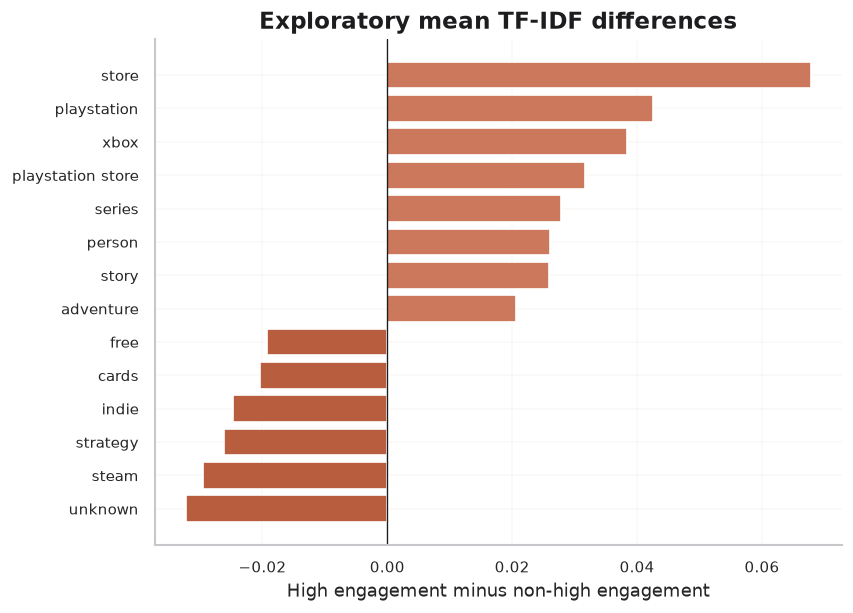

In [11]:
# Training-only exploratory text signal audit
text_source = df[["all_genres", "theme", "all_tags", "description_clean", "available_stores"]].fillna("").astype(str).agg(" ".join, axis=1)
text_source_train = text_source.loc[train_index]
text_target_train = df.loc[train_index, "high_engagement"]
text_vectorizer = TfidfVectorizer(max_features=100, min_df=25, stop_words="english", ngram_range=(1, 2))
tfidf_matrix = text_vectorizer.fit_transform(text_source_train)
text_terms = np.asarray(text_vectorizer.get_feature_names_out())
high_mask = text_target_train.to_numpy() == 1
high_mean = np.asarray(tfidf_matrix[high_mask].mean(axis=0)).ravel()
low_mean = np.asarray(tfidf_matrix[~high_mask].mean(axis=0)).ravel()
text_signal = pd.DataFrame({"term": text_terms, "high_mean_tfidf": high_mean, "non_high_mean_tfidf": low_mean, "difference": high_mean - low_mean}).sort_values("difference", ascending=False).reset_index(drop=True)
display(pd.concat([text_signal.head(12), text_signal.tail(8)]))
text_signal.to_csv(OUTPUT_DIR / "rebuild_text_signal_terms.csv", index=False)

plot_terms = pd.concat([text_signal.head(8), text_signal.tail(6)]).sort_values("difference")
fig, ax = plt.subplots(figsize=FIG_SINGLE, constrained_layout=True)
ax.barh(plot_terms["term"], plot_terms["difference"], color=[PALETTE[1] if x < 0 else PALETTE[0] for x in plot_terms["difference"]])
ax.axvline(0, color=INK, linewidth=.8)
ax.set(title="Exploratory mean TF-IDF differences", xlabel="High engagement minus non-high engagement", ylabel="")
save_multi(fig, "rebuild_text_signal_terms")
plt.show()

term_lookup = text_signal.set_index("term")["difference"]
def term_diff(term):
    return float(term_lookup.get(term, np.nan))

### Evidence-led interpretation

**Analytical question.** Do game descriptions, tags and platform listings contain language that helps distinguish the two engagement groups?

**Numerical evidence.** The largest positive mean TF-IDF differences are `store` (**+0.0678**), `playstation` (**+0.0425**) and `xbox` (**+0.0384**). The strongest negative contrasts include `unknown` (**-0.0323**), `steam` (**-0.0295**) and `strategy` (**-0.0262**).

**Judgement.** The strongest contrasts mix distribution language, genre conventions and documentation completeness. They are plausible screening signals because they summarise how titles are described and listed, not because the words themselves improve engagement.

**Alternative explanation.** `Unknown` may proxy incomplete metadata; `store`, `PlayStation` and `Xbox` may proxy platform coverage; and genre terms may reflect the segment composition already seen in the descriptive tables.

**Decision consequence.** Use text to enrich comparable-game search and model ranking, but do not turn individual tokens into product-copy or design prescriptions.


---
## 8. Leakage-Safe Model Design

Three evidence sets answer distinct operational questions:

- **A - design and distribution screening:** design metadata plus current platform/store coverage for comparable-market screening and planning.
- **A without platform - paired ablation:** the same rows, estimator and folds after removing platform breadth and platform/store text.
- **B - post-launch diagnostic:** adds ratings, reviews and playtime for monitoring after launch.

Feature set A should **not be interpreted as a pure pre-launch forecasting model** because current platform and store coverage may include later porting decisions. It is a stage-matched market-screening model, whereas B deliberately describes an after-launch diagnostic ceiling.

Every learned imputer, encoder, scaler and TF-IDF vocabulary remains inside the pipeline. Five stratified folds operate only on the 12,000 training games. The 3,000-game holdout is excluded from preprocessing, vocabulary construction and estimator choice. **No hyperparameter tuning was performed**: all model settings were pre-specified and retained for this comparison.

### Train/holdout split rationale

The dataset is split once into an 80% training set and a 20% locked holdout set using stratification on the high-engagement outcome. Stratification preserves the approximately 25% positive rate in both samples. All estimator selection, cross-validation, preprocessing, imputation, encoding and TF-IDF vocabulary fitting occur inside the training process only. The holdout is reserved for a **locked pre-specified final evaluation suite** covering discrimination, capacity lift, error burden, ablation diagnostics and decision simulation. These related evaluations are reported transparently as one final suite rather than described as repeated model-selection evidence. The later chronological sensitivity test separately checks temporal fragility.


### Predictor Selection Rationale

| Variable group | Included in main model? | Rationale | Caution |
|---|---|---|---|
| Design metadata | Yes | Reflects product positioning, genre, theme, mode and comparable-game characteristics. | Associations should not be interpreted as causal design effects. |
| Platform and distribution metadata | Yes | Useful for benchmarking market reach and distribution footprint. | May partly reflect later porting or publisher support rather than original launch decisions. |
| Franchise and release context | Yes | Captures series depth, IP context and market timing. | May proxy budget, brand strength or accumulated audience. |
| Metadata text fields | Yes | Tags and descriptions help represent product positioning and market language. | Important terms indicate model reliance, not direct causal drivers. |
| Post-launch ratings, reviews and playtime | Diagnostic only | Useful for post-launch monitoring and comparison. | Excluded from the main stage-matched model to avoid reception leakage. |
| Status, library and popularity fields | No | Too close to the engagement outcome. | Excluded to avoid using outcome-like variables as predictors. |
| Identifiers, URLs and image fields | No | Do not provide generalisable business signals. | Excluded to avoid memorisation and noise. |

This boundary is deliberately labelled **stage-matched screening**, not pure pre-launch forecasting: current platform/store coverage can include later porting, while reception variables remain confined to the diagnostic comparison.


In [12]:
# Leakage-safe feature sets and business-aligned scoring
LEAKAGE_RISK_COLUMNS = {
    "engagement_score", "popularity_score", "library_count", "status_owned", "status_beaten",
    "status_playing", "status_dropped", "status_toplay", "status_yet", "high_engagement",
}
screening_numeric = ["release_year", "platform_count", "is_multiplayer", "is_multi_platform", "achievements_count", "game_series_count"]
screening_categorical = ["theme", "art_style", "view_dimension", "game_mode", "controls", "esrb_rating", "decade"]
postlaunch_numeric = ["user_rating", "metacritic", "ratings_count", "reviews_count", "avg_playtime_hours"]

feature_sets = {
    "A_design_distribution_screening": {
        "numeric": screening_numeric,
        "categorical": screening_categorical,
        "texts": ["design_text", "platform_text"],
        "explanation": "Design metadata plus current platform/store coverage for stage-matched screening.",
    },
    "A_no_platform_ablation": {
        "numeric": [c for c in screening_numeric if c not in {"platform_count", "is_multi_platform"}],
        "categorical": screening_categorical,
        "texts": ["design_text"],
        "explanation": "Same stage-matched evidence without platform breadth or platform/store text.",
    },
    "B_postlaunch_diagnostic": {
        "numeric": screening_numeric + postlaunch_numeric,
        "categorical": screening_categorical,
        "texts": ["design_text", "platform_text"],
        "explanation": "Adds ratings, reviews and playtime for after-launch monitoring only.",
    },
}

for name, spec in feature_sets.items():
    candidate_columns = set(spec["numeric"] + spec["categorical"] + spec["texts"])
    leaked = candidate_columns.intersection(LEAKAGE_RISK_COLUMNS)
    assert not leaked, f"{name} contains leakage columns: {leaked}"
    print(name, len(candidate_columns), "input columns; leakage:", sorted(leaked))


# Score the same fixed capacity used by the business decision simulation.
def select_top_k(item_ids, scores, capacity, seed=RANDOM_STATE):
    """Return item IDs ranked by score with one deterministic seeded tie policy."""
    item_index = pd.Index(item_ids)
    score_array = np.asarray(scores, dtype=float)
    if len(item_index) != len(score_array):
        raise ValueError("item_ids and scores must have equal length")
    if not item_index.is_unique:
        raise ValueError("item_ids must be unique")
    if 0 < capacity <= 1:
        k = int(np.ceil(len(item_index) * float(capacity)))
    else:
        k = int(capacity)
    k = min(max(k, 0), len(item_index))
    tie_keys = [
        hashlib.sha256(f"{seed}|{item_id}".encode("utf-8")).hexdigest()
        for item_id in item_index
    ]
    ranking = pd.DataFrame({
        "position": np.arange(len(item_index)),
        "score": np.nan_to_num(score_array, nan=-np.inf),
        "tie_key": tie_keys,
    }).sort_values(
        ["score", "tie_key", "position"],
        ascending=[False, True, True],
        kind="mergesort",
    )
    return pd.Index(item_index.take(ranking["position"].iloc[:k]), name=item_index.name)


def top_k_metrics(y_true, scores, item_ids, capacity=0.20):
    """Calculate precision, lift and capture at a fixed review capacity."""
    item_index = pd.Index(item_ids)
    y_array = np.asarray(y_true, dtype=int)
    selected_ids = select_top_k(item_index, scores, capacity)
    selected_mask = item_index.isin(selected_ids)
    reviewed = int(selected_mask.sum())
    captured = int(y_array[selected_mask].sum())
    total_positive = int(y_array.sum())
    base_rate = float(y_array.mean())
    precision = captured / reviewed if reviewed else np.nan
    return {
        "reviewed": reviewed,
        "captured": captured,
        "precision": precision,
        "lift": precision / base_rate if base_rate else np.nan,
        "capture": captured / total_positive if total_positive else np.nan,
    }


# Fit all imputation, encoding, and text transforms inside the CV pipeline.
def build_preprocessor(spec, scale_numeric: bool) -> ColumnTransformer:
    numeric_steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    transformers = [
        ("num", Pipeline(numeric_steps), spec["numeric"]),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50)),
        ]), spec["categorical"]),
    ]
    for text_column in spec["texts"]:
        transformers.append((
            f"text_{text_column}",
            TfidfVectorizer(max_features=90, min_df=35, stop_words="english", ngram_range=(1, 2)),
            text_column,
        ))
    return ColumnTransformer(transformers, remainder="drop", verbose_feature_names_out=True)


models = {
    "Dummy_prior": DummyClassifier(strategy="prior", random_state=RANDOM_STATE),
    "LogisticRegression_baseline": LogisticRegression(max_iter=1500, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE),
    "DecisionTree_interpretable": DecisionTreeClassifier(max_depth=5, min_samples_leaf=60, class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForest_flexible": RandomForestClassifier(n_estimators=100, min_samples_leaf=30, max_depth=14, max_features="sqrt", class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE),
}


def build_pipeline(spec, model_name):
    scale_numeric = model_name == "LogisticRegression_baseline"
    return Pipeline([
        ("preprocessor", build_preprocessor(spec, scale_numeric=scale_numeric)),
        ("model", clone(models[model_name])),
    ])


def _top20_metric_scorer(estimator, X, y_true, metric):
    score = estimator.predict_proba(X)[:, 1]
    return top_k_metrics(y_true, score, X.index, capacity=0.20)[metric]


def top20_precision_scorer(estimator, X, y_true):
    return _top20_metric_scorer(estimator, X, y_true, "precision")


def top20_lift_scorer(estimator, X, y_true):
    return _top20_metric_scorer(estimator, X, y_true, "lift")


def top20_capture_scorer(estimator, X, y_true):
    return _top20_metric_scorer(estimator, X, y_true, "capture")


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# Evaluate ranking quality and equal-capacity commercial usefulness together.
scoring = {
    "roc_auc": "roc_auc", "pr_auc": "average_precision",
    "f1": make_scorer(f1_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "balanced_accuracy": "balanced_accuracy", "accuracy": "accuracy",
    "top20_precision": top20_precision_scorer,
    "top20_lift": top20_lift_scorer,
    "top20_capture": top20_capture_scorer,
}


A_design_distribution_screening 15 input columns; leakage: []
A_no_platform_ablation 12 input columns; leakage: []
B_postlaunch_diagnostic 20 input columns; leakage: []


A_design_distribution_screening Dummy_prior Top-20% lift=0.929 PR AUC=0.250 ROC AUC=0.500


A_design_distribution_screening LogisticRegression_baseline Top-20% lift=2.741 PR AUC=0.703 ROC AUC=0.855


A_design_distribution_screening DecisionTree_interpretable Top-20% lift=2.563 PR AUC=0.602 ROC AUC=0.809


A_design_distribution_screening RandomForest_flexible Top-20% lift=2.762 PR AUC=0.712 ROC AUC=0.859


A_no_platform_ablation Dummy_prior Top-20% lift=0.929 PR AUC=0.250 ROC AUC=0.500


...

B_postlaunch_diagnostic Dummy_prior Top-20% lift=0.929 PR AUC=0.250 ROC AUC=0.500


B_postlaunch_diagnostic LogisticRegression_baseline Top-20% lift=3.051 PR AUC=0.789 ROC AUC=0.895


B_postlaunch_diagnostic DecisionTree_interpretable Top-20% lift=2.943 PR AUC=0.737 ROC AUC=0.889


B_postlaunch_diagnostic RandomForest_flexible Top-20% lift=3.175 PR AUC=0.830 ROC AUC=0.926


feature_set,model,feature_set_explanation,evaluation_scope,fold_count,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std,top20_precision_mean,top20_precision_std,top20_lift_mean,top20_lift_std,top20_capture_mean,top20_capture_std
A_design_distribution_screening,RandomForest_flexible,Design metadata plus current platform/store coverage for stage-matched screening.,training_only_5fold_cv,5,0.858565,0.004007,0.711980,0.006896,0.616137,0.005402,0.552223,0.010571,0.697206,0.015070,0.754194,0.004383,0.782667,0.005477,0.690833,0.018552,2.761500,0.074448,0.552300,0.014890
A_design_distribution_screening,LogisticRegression_baseline,Design metadata plus current platform/store coverage for stage-matched screening.,training_only_5fold_cv,5,0.854548,0.007727,0.703098,0.017764,0.615689,0.017572,0.528487,0.022668,0.737836,0.011372,0.758840,0.012128,0.769333,0.014585,0.685833,0.012792,2.741473,0.048788,0.548295,0.009758
A_design_distribution_screening,DecisionTree_interpretable,Design metadata plus current platform/store coverage for stage-matched screening.,training_only_5fold_cv,5,0.809057,0.006449,0.602042,0.018144,0.587852,0.004798,0.546879,0.036124,0.641226,0.051275,0.730425,0.005390,0.775000,0.019192,0.641250,0.011913,2.563261,0.045495,0.512652,0.009099
A_design_distribution_screening,Dummy_prior,Design metadata plus current platform/store coverage for stage-matched screening.,training_only_5fold_cv,5,0.500000,0.000000,0.250167,0.000228,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.749833,0.000228,0.232500,0.014328,0.929401,0.057645,0.185880,0.011529
A_no_platform_ablation,RandomForest_flexible,Same stage-matched evidence without platform breadth or platform/store text.,training_only_5fold_cv,5,0.855173,0.006292,0.696265,0.012967,0.616649,0.007020,0.553958,0.014509,0.695875,0.013759,0.754306,0.004691,0.783500,0.007578,0.676250,0.011277,2.703222,0.046824,0.540644,0.009365
A_no_platform_ablation,LogisticRegression_baseline,Same stage-matched evidence without platform breadth or platform/store text.,training_only_5fold_cv,5,0.840642,0.006667,0.670368,0.017849,0.600595,0.014658,0.507722,0.018796,0.735511,0.011694,0.748564,0.010731,0.755083,0.013328,0.653750,0.021113,2.613206,0.082283,0.522641,0.016457
A_no_platform_ablation,DecisionTree_interpretable,Same stage-matched evidence without platform breadth or platform/store text.,training_only_5fold_cv,5,0.796249,0.004055,0.581139,0.015996,0.571413,0.009857,0.520730,0.016513,0.633577,0.014991,0.719323,0.006843,0.762167,0.009135,0.630833,0.011730,2.521656,0.047079,0.504331,0.009416
A_no_platform_ablation,Dummy_prior,Same stage-matched evidence without platform breadth or platform/store text.,training_only_5fold_cv,5,0.500000,0.000000,0.250167,0.000228,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.749833,0.000228,0.232500,0.014328,0.929401,0.057645,0.185880,0.011529
B_postlaunch_diagnostic,RandomForest_flexible,"Adds ratings, reviews and playtime for after-launch monitoring only.",training_only_5fold_cv,5,0.925520,0.003521,0.829652,0.012555,0.725517,0.008109,0.653193,0.012073,0.816118,0.013132,0.835710,0.005808,0.845500,0.005523,0.794167,0.010354,3.174562,0.042363,0.634912,0.008473
B_postlaunch_diagnostic,LogisticRegression_baseline,"Adds ratings, reviews and playtime for after-launch monitoring only.",training_only_5fold_cv,5,0.895372,0.006866,0.789149,0.011219,0.665123,0.015480,0.583421,0.021072,0.773814,0.010467,0.794554,0.009894,0.804917,0.011753,0.763333,0.008665,3.051298,0.034363,0.610260,0.006873


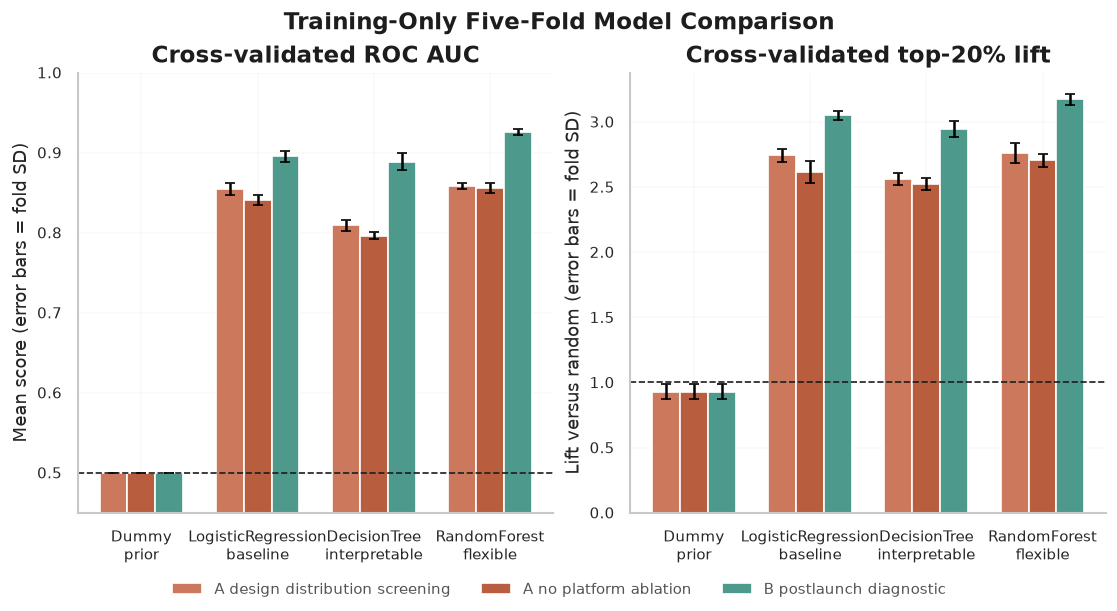

Primary selection metric: mean top-20% lift
Selected stage-matched screening model from training CV only: RandomForest_flexible


In [13]:
# Training-only model comparison and selection
y_train = df.loc[train_index, "high_engagement"]
# Compare candidates on identical folds; the holdout remains untouched.
model_rows = []
for feature_set_name, spec in feature_sets.items():
    columns = spec["numeric"] + spec["categorical"] + spec["texts"]
    X_train_set = df.loc[train_index, columns].copy()
    for model_name in models:
        pipeline = build_pipeline(spec, model_name)
        cv_scores = cross_validate(
            pipeline, X_train_set, y_train, cv=cv, scoring=scoring,
            n_jobs=1, error_score="raise",
        )
        row = {
            "feature_set": feature_set_name, "model": model_name,
            "feature_set_explanation": spec["explanation"],
            "evaluation_scope": "training_only_5fold_cv", "fold_count": 5,
        }
        for metric in scoring:
            values = cv_scores[f"test_{metric}"]
            row[f"{metric}_mean"] = values.mean()
            row[f"{metric}_std"] = values.std(ddof=1)
        model_rows.append(row)
        print(
            feature_set_name, model_name,
            f"Top-20% lift={row['top20_lift_mean']:.3f}",
            f"PR AUC={row['pr_auc_mean']:.3f}",
            f"ROC AUC={row['roc_auc_mean']:.3f}",
        )

model_comparison = pd.DataFrame(model_rows).sort_values(
    ["feature_set", "top20_lift_mean", "pr_auc_mean", "roc_auc_mean"],
    ascending=[True, False, False, False],
).reset_index(drop=True)
display_wrapped_table(
    model_comparison,
    caption="Training-only cross-validation model comparison",
    hide_index=True,
)
model_comparison.to_csv(OUTPUT_DIR / "rebuild_model_comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=FIG_WIDE, constrained_layout=True)
feature_order = list(feature_sets)
model_order = list(models)
x = np.arange(len(model_order))
width = 0.24
colors = PALETTE  # use global unified palette
for j, feature_set_name in enumerate(feature_order):
    subset = model_comparison.set_index(["feature_set", "model"]).loc[feature_set_name].reindex(model_order)
    positions = x + (j - 1) * width
    label = feature_set_name.replace("_", " ")
    axes[0].bar(
        positions, subset["roc_auc_mean"], width,
        yerr=subset["roc_auc_std"], capsize=3, color=colors[j], label=label,
    )
    axes[1].bar(
        positions, subset["top20_lift_mean"], width,
        yerr=subset["top20_lift_std"], capsize=3, color=colors[j], label=label,
    )
axes[0].axhline(.5, color=INK, linestyle="--", linewidth=1)
axes[1].axhline(1.0, color=INK, linestyle="--", linewidth=1)
for ax in axes:
    ax.set_xticks(x, [m.replace("_", "\n") for m in model_order])
axes[0].set(title="Cross-validated ROC AUC", ylabel="Mean score (error bars = fold SD)", ylim=(.45, 1.0))
axes[1].set(title="Cross-validated top-20% lift", ylabel="Lift versus random (error bars = fold SD)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=3)
fig.suptitle("Training-Only Five-Fold Model Comparison", fontsize=14, fontweight="bold")
save_multi(fig, "rebuild_model_comparison")
plt.show()

screening_results = model_comparison.query(
    "feature_set == 'A_design_distribution_screening' and model != 'Dummy_prior'"
)
best_row = screening_results.sort_values(
    ["top20_lift_mean", "pr_auc_mean", "roc_auc_mean"], ascending=False
).iloc[0]
# Select by the pre-declared top-20% lift objective with deterministic ties.
best_model_name = best_row["model"]
best_spec = feature_sets["A_design_distribution_screening"]
print("Primary selection metric: mean top-20% lift")
print("Selected stage-matched screening model from training CV only:", best_model_name)


### Critical Interpretation of Training-Only Model Selection

**Analytical question.** Does the training-only comparison justify selecting Random Forest for the locked evaluation, and how strong is that claim?

**Numerical evidence.** Random Forest records **2.762x** mean top-20% lift, while Logistic Regression records **2.741x**. This **narrow advantage** is useful for a pre-declared capacity objective, but it is not an overwhelming separation. The higher post-launch diagnostic score is best read as a **diagnostic ceiling**, **not evidence for planning-stage deployment**.

**Judgement.** Random Forest is therefore a **capacity-aligned pragmatic choice** for the next evaluation step, not proof that complex models are generally superior. Logistic Regression remains a credible, simpler challenger.

**Alternative explanations and boundary conditions.** The comparison uses **fixed, pre-specified settings** without hyperparameter tuning, so the winner should not be described as the **globally best model**. In addition, platform and store fields can reflect **later porting** or distribution expansion; even the stage-matched specification is therefore **not a pure pre-launch forecast**.

**Decision consequence.** Proceed with Random Forest because it leads on the stated training-only capacity metric, but keep the claim deliberately local: one dataset, one split policy, fixed candidates, and a planning-stage evidence approximation. Use the post-launch model only to quantify how much signal becomes available after market response is observed.

---
## 9. Model Evaluation

The locked holdout supports a **pre-specified final evaluation suite**: discrimination, capacity lift, error analysis, platform ablation diagnostics and decision simulation. Bootstrap intervals quantify sampling uncertainty. These holdout diagnostics inform governance and limitations; they do not reopen model selection.


,selected_model,roc_auc,pr_auc,f1,precision,recall,balanced_accuracy,accuracy,roc_auc_ci_low,roc_auc_ci_high,pr_auc_ci_low,pr_auc_ci_high,f1_ci_low,f1_ci_high,holdout_rows,holdout_positive_rate
0,RandomForest_flexible,0.868671,0.7148,0.63466,0.565762,0.722667,0.768889,0.792,0.855317,0.881459,0.680803,0.74631,0.606317,0.659491,3000,0.25


,class_or_average,precision,recall,f1-score,support
0,0,0.898139,0.815111,0.854613,2250.000
1,1,0.565762,0.722667,0.634660,750.000
2,accuracy,0.792000,0.792000,0.792000,0.792
3,macro avg,0.731951,0.768889,0.744637,3000.000
4,weighted avg,0.815045,0.792000,0.799625,3000.000


,pred_non_high,pred_high
actual_non_high,1834,416
actual_high,208,542


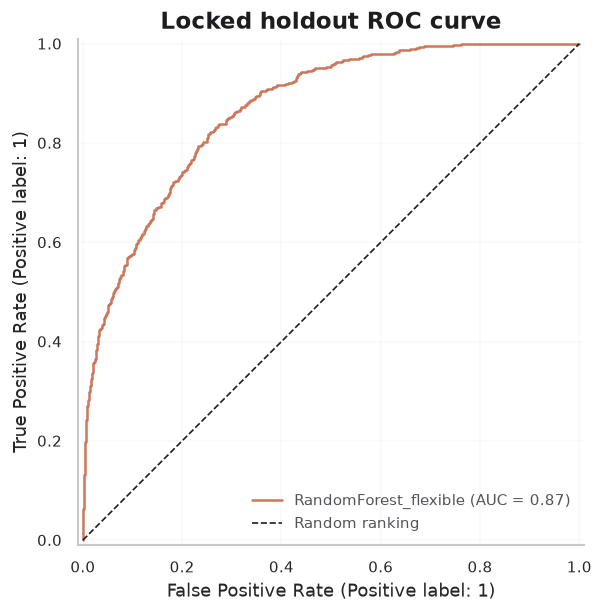

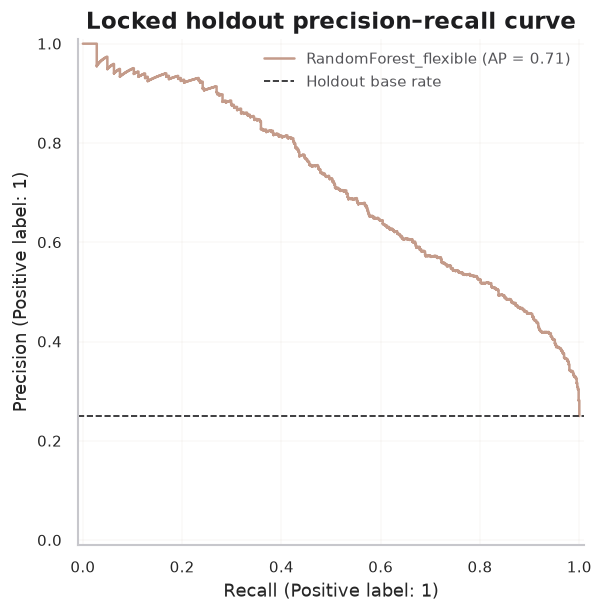

In [14]:
# Locked holdout fit and uncertainty
main_columns = best_spec["numeric"] + best_spec["categorical"] + best_spec["texts"]
X_train_main = df.loc[train_index, main_columns].copy()
X_holdout = df.loc[holdout_index, main_columns].copy()
y_holdout = df.loc[holdout_index, "high_engagement"]

# Refit the selected pipeline once on all training rows, then unlock the holdout.
main_pipeline = build_pipeline(best_spec, best_model_name)
main_pipeline.fit(X_train_main, y_train)
holdout_pred = main_pipeline.predict(X_holdout)
holdout_prob = main_pipeline.predict_proba(X_holdout)[:, 1]

# Bootstrap the locked predictions to show sampling uncertainty in ranking metrics.
def bootstrap_metric_ci(y_true, y_pred, y_prob, metric, n_boot=1000, seed=RANDOM_STATE):
    local_rng = np.random.default_rng(seed)
    values = []
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred); y_prob = np.asarray(y_prob)
    for _ in range(n_boot):
        idx = local_rng.integers(0, len(y_true), len(y_true))
        if np.unique(y_true[idx]).size < 2 and metric in {"roc_auc", "pr_auc"}:
            continue
        if metric == "roc_auc": values.append(roc_auc_score(y_true[idx], y_prob[idx]))
        elif metric == "pr_auc": values.append(average_precision_score(y_true[idx], y_prob[idx]))
        elif metric == "f1": values.append(f1_score(y_true[idx], y_pred[idx], zero_division=0))
    return tuple(np.quantile(values, [.025, .975]))

holdout_values = {
    "roc_auc": roc_auc_score(y_holdout, holdout_prob),
    "pr_auc": average_precision_score(y_holdout, holdout_prob),
    "f1": f1_score(y_holdout, holdout_pred, zero_division=0),
    "precision": precision_score(y_holdout, holdout_pred, zero_division=0),
    "recall": recall_score(y_holdout, holdout_pred, zero_division=0),
    "balanced_accuracy": balanced_accuracy_score(y_holdout, holdout_pred),
    "accuracy": accuracy_score(y_holdout, holdout_pred),
}
auc_ci = bootstrap_metric_ci(y_holdout, holdout_pred, holdout_prob, "roc_auc")
pr_ci = bootstrap_metric_ci(y_holdout, holdout_pred, holdout_prob, "pr_auc")
f1_ci = bootstrap_metric_ci(y_holdout, holdout_pred, holdout_prob, "f1")

holdout_metrics = pd.DataFrame([{
    "selected_model": best_model_name, **holdout_values,
    "roc_auc_ci_low": auc_ci[0], "roc_auc_ci_high": auc_ci[1],
    "pr_auc_ci_low": pr_ci[0], "pr_auc_ci_high": pr_ci[1],
    "f1_ci_low": f1_ci[0], "f1_ci_high": f1_ci[1],
    "holdout_rows": len(y_holdout), "holdout_positive_rate": y_holdout.mean(),
}])
display(holdout_metrics)
holdout_metrics.to_csv(OUTPUT_DIR / "rebuild_holdout_metrics.csv", index=False)
holdout_metrics.to_csv(OUTPUT_DIR / "model_holdout_metrics.csv", index=False)

final_model_feature_list = pd.DataFrame({
    "feature": main_columns,
    "feature_set": "A_design_distribution_screening",
    "business_role": ["planning/screening input"] * len(main_columns),
})
final_model_feature_list.to_csv(OUTPUT_DIR / "final_model_feature_list.csv", index=False)

report_table = pd.DataFrame(classification_report(y_holdout, holdout_pred, output_dict=True, zero_division=0)).T.reset_index().rename(columns={"index": "class_or_average"})
cm = confusion_matrix(y_holdout, holdout_pred)
cm_table = pd.DataFrame(cm, index=["actual_non_high", "actual_high"], columns=["pred_non_high", "pred_high"])
display(report_table); display(cm_table)
report_table.to_csv(OUTPUT_DIR / "rebuild_classification_report.csv", index=False)
cm_table.to_csv(OUTPUT_DIR / "rebuild_confusion_matrix.csv")

fig, ax = plt.subplots(figsize=FIG_SINGLE, constrained_layout=True)
RocCurveDisplay.from_predictions(
    y_holdout, holdout_prob, name=best_model_name, ax=ax,
    curve_kwargs={"color": PALETTE[0]},
)
ax.plot([0, 1], [0, 1], linestyle="--", color=INK, linewidth=1, label="Random ranking")
ax.set_title("Locked holdout ROC curve")
ax.legend(loc="lower right")
save_multi(fig, "roc_curve")
plt.show()

fig, ax = plt.subplots(figsize=FIG_SINGLE, constrained_layout=True)
PrecisionRecallDisplay.from_predictions(
    y_holdout, holdout_prob, name=best_model_name, ax=ax,
    curve_kwargs={"color": PALETTE[3]},
)
ax.axhline(y_holdout.mean(), linestyle="--", color=INK, linewidth=1, label="Holdout base rate")
ax.set_title("Locked holdout precision–recall curve")
ax.legend(loc="upper right")
save_multi(fig, "precision_recall_curve")
plt.show()

fp_share = 1 - holdout_values["precision"]
miss_share = 1 - holdout_values["recall"]


### Evidence-led interpretation

**Analytical question.** Does the selected model retain useful ranking performance when evaluated once on the untouched holdout?

**Numerical evidence.** In the **locked final evaluation suite**, Random Forest achieves **ROC AUC 0.869** alongside the reported PR AUC, Brier score, top-20% lift, confusion matrix, and bootstrap intervals above. These measures answer different questions: discrimination, minority-class retrieval, probability error, capacity value, and sampling uncertainty.

**Judgement.** The holdout confirms strong ranking value for prioritisation, but the result supports a decision aid rather than an automatic launch rule. Performance should be read with the uncertainty intervals and the equal-capacity benchmark, not from a single headline metric.

**Alternative explanation.** A stratified random holdout preserves class balance but cannot fully reproduce future catalogue drift, changing platform strategies, or shifts in how engagement is recorded. Correlated franchise and design signals may also make apparently novel successes easier to rank than genuinely new concepts.

**Decision consequence.** Use the ranking to allocate a fixed review or investment capacity, monitor realised lift after deployment, and trigger revalidation when the game mix or data-collection process changes. The later chronological sensitivity analysis is the stronger stress test for temporal generalisation.


---
## 10. Business Screening Threshold and Lift Analysis

The managerial question is whether ranking improves a constrained research process. If analysts can inspect only the top 10%, 20% or 25% of holdout games, the relevant outcomes are how many genuinely high-engagement comparables enter the queue, how precise that queue is and how much it improves on random screening. These are components of the locked pre-specified final evaluation suite and all use the same deterministic tie-breaking policy.


In [15]:
# Capacity-based ranking and lift
def screening_lift_table(y_true, y_prob, item_ids, cutoffs=(0.10, 0.20, 0.25)):
    """Summarise ranking value at fixed review-budget shares."""
    y_array = np.asarray(y_true, dtype=int)
    item_index = pd.Index(item_ids)
    rows = []
    for cutoff in cutoffs:
        metrics = top_k_metrics(y_array, y_prob, item_index, capacity=cutoff)
        rows.append({
            "screening_group": f"Top {int(cutoff * 100)}% predicted",
            "games_reviewed": metrics["reviewed"],
            "review_share": metrics["reviewed"] / len(y_array),
            "high_engagement_games_captured": metrics["captured"],
            "capture_rate": metrics["capture"],
            "precision": metrics["precision"],
            "lift_vs_random": metrics["lift"],
        })
    return pd.DataFrame(rows)


screening_lift = screening_lift_table(y_holdout, holdout_prob, y_holdout.index)
display(screening_lift.style.format({
    "review_share": "{:.1%}", "capture_rate": "{:.1%}",
    "precision": "{:.1%}", "lift_vs_random": "{:.2f}×",
}))
screening_lift.to_csv(OUTPUT_DIR / "screening_lift_table.csv", index=False)
screening_lift.to_csv(OUTPUT_DIR / "rebuild_screening_lift_table.csv", index=False)


,screening_group,games_reviewed,review_share,high_engagement_games_captured,capture_rate,precision,lift_vs_random
0,Top 10% predicted,300,10.0%,256,34.1%,85.3%,3.41×
1,Top 20% predicted,600,20.0%,413,55.1%,68.8%,2.75×
2,Top 25% predicted,750,25.0%,469,62.5%,62.5%,2.50×


### Evidence-led interpretation

**Analytical question.** How much value does the model create at realistic review capacities?

**Numerical evidence.** Reviewing the top **10% (300 games)** captures **256 positives**, giving **34.1% capture**, **85.3% precision** and **3.41x lift**. At the chosen **20% capacity (600 games)**, the queue captures **413 positives**, or **55.1%** of all positives, with **68.8% precision** and **2.75x lift**. Expanding to **25% (750 games)** captures **469 positives (62.5%)**, but lift falls to **2.50x**.

**Judgement.** The ranking concentrates opportunity substantially better than random review, while showing diminishing returns as capacity expands. The 20% queue balances coverage and workload more plausibly than selecting a threshold solely for accuracy.

**Alternative explanation.** Lift evaluates prioritisation within the locked holdout; it does not make the scores calibrated causal probabilities or guarantee that the same concentration will persist in a changing market.

**Decision consequence.** Use a capacity-based queue and monitor capture, precision and missed opportunities rather than deploying a universal 0.5 classification cutoff.

### Holdout Score-Decile Ranking Analysis

The score-decile table provides a second ordering check: a useful model should place progressively more observed positives in the highest score bands. It is a ranking diagnostic, **not a calibration assessment** and not evidence that the scores are causal success probabilities.


### Target-Definition Sensitivity

The fixed 4.25 outcome remains the primary specification. This sensitivity test asks whether ranking value survives nearby top-20%, top-25% and top-30% definitions. Each alternative threshold is estimated from training engagement values only; feature membership, estimator and pre-specified model settings remain frozen, and no sensitivity result is used to replace the selected model.


In [16]:
# Training-defined target-threshold sensitivity
TARGET_POSITIVE_SHARES = (0.20, 0.25, 0.30)
target_sensitivity_rows = []

for target_share in TARGET_POSITIVE_SHARES:
    threshold = float(
        df.loc[train_index, "engagement_score"].quantile(1 - target_share)
    )
    y_train_sensitivity = (
        df.loc[train_index, "engagement_score"] >= threshold
    ).astype(int)
    y_holdout_sensitivity = (
        df.loc[holdout_index, "engagement_score"] >= threshold
    ).astype(int)

    sensitivity_pipeline = build_pipeline(best_spec, best_model_name)
    sensitivity_pipeline.fit(X_train_main, y_train_sensitivity)
    sensitivity_prob = sensitivity_pipeline.predict_proba(X_holdout)[:, 1]
    sensitivity_top20 = screening_lift_table(
        y_holdout_sensitivity, sensitivity_prob, y_holdout_sensitivity.index, cutoffs=(0.20,)
    ).iloc[0]

    target_sensitivity_rows.append({
        "target_positive_share": target_share,
        "training_quantile": 1 - target_share,
        "training_threshold": threshold,
        "training_positive_rate": y_train_sensitivity.mean(),
        "holdout_positive_rate": y_holdout_sensitivity.mean(),
        "roc_auc": roc_auc_score(y_holdout_sensitivity, sensitivity_prob),
        "pr_auc": average_precision_score(y_holdout_sensitivity, sensitivity_prob),
        "top20_precision": sensitivity_top20["precision"],
        "top20_capture_rate": sensitivity_top20["capture_rate"],
        "top20_lift": sensitivity_top20["lift_vs_random"],
    })

target_threshold_sensitivity = pd.DataFrame(target_sensitivity_rows)
display(target_threshold_sensitivity.style.format({
    "target_positive_share": "{:.0%}",
    "training_positive_rate": "{:.1%}",
    "holdout_positive_rate": "{:.1%}",
    "roc_auc": "{:.3f}",
    "pr_auc": "{:.3f}",
    "top20_precision": "{:.1%}",
    "top20_capture_rate": "{:.1%}",
    "top20_lift": "{:.2f}×",
}))
target_threshold_sensitivity.to_csv(
    OUTPUT_DIR / "target_threshold_sensitivity.csv", index=False
)

minimum_sensitivity_lift = target_threshold_sensitivity["top20_lift"].min()


,target_positive_share,training_quantile,training_threshold,training_positive_rate,holdout_positive_rate,roc_auc,pr_auc,top20_precision,top20_capture_rate,top20_lift
0,20%,0.800000,5.550000,20.1%,19.6%,0.866,0.658,56.2%,57.3%,2.87×
1,25%,0.750000,4.250000,25.0%,25.0%,0.869,0.715,68.8%,55.1%,2.75×
2,30%,0.700000,3.430000,30.0%,29.2%,0.864,0.750,76.5%,52.3%,2.62×


### Evidence-led interpretation

**Analytical question.** Is the screening conclusion an artefact of choosing exactly the upper quartile?

**Numerical evidence.** Training-derived thresholds are **5.55**, **4.25** and **3.43** for the top-20%, top-25% and top-30% outcomes. Their holdout ROC AUC values are tightly grouped at **0.866**, **0.869** and **0.864**. At 20% review capacity, lift remains **2.87x**, **2.75x** and **2.62x**, while capture ranges from **57.3%** to **52.3%**.

**Judgement.** Ranking value is not dependent on one exact quartile boundary. The modest decline in lift as the positive class broadens is expected because random screening becomes a stronger baseline.

**Alternative explanation.** Robustness across nearby cutoffs cannot validate the unknown construction of `engagement_score`; it only shows that the fitted ranking is not brittle to these three business conventions.

**Decision consequence.** Retain 4.25 for comparability and use the sensitivity range as governance evidence rather than an additional model-selection exercise.


### Stage-Matched Heuristic Benchmarks

The final model is compared with rules a manager could apply at the same information stage: platform breadth, franchise depth and equal-weight metadata breadth. Ratings, reviews, Metacritic and playtime are excluded because they are post-launch signals and may overlap with the target. The winning simple rule is chosen on training data before its holdout performance is compared with the ML queue. Every realised queue uses the same seeded hash tie-breaker, preventing arbitrary row order from changing the result.


In [17]:
# Stage-matched heuristic benchmark
PLANNING_HEURISTIC_COLUMNS = [
    "platform_count", "game_series_count", "achievements_count"
]

def planning_heuristic_scores(data):
    scores = pd.DataFrame(index=data.index)
    scores["Platform breadth"] = data["platform_count"].rank(
        method="average", pct=True
    )
    scores["Franchise depth"] = data["game_series_count"].rank(
        method="average", pct=True
    )
    scores["Equal-weight metadata breadth"] = pd.concat(
        [
            data[column].rank(method="average", pct=True)
            for column in PLANNING_HEURISTIC_COLUMNS
        ],
        axis=1,
    ).mean(axis=1)
    return scores

train_heuristic_scores = planning_heuristic_scores(df.loc[train_index])
holdout_heuristic_scores = planning_heuristic_scores(df.loc[holdout_index])

training_heuristic_rows = []
for method in train_heuristic_scores.columns:
    top20 = screening_lift_table(
        y_train, train_heuristic_scores[method], y_train.index, cutoffs=(0.20,)
    ).iloc[0]
    training_heuristic_rows.append({
        "method": method,
        "top20_precision": top20["precision"],
        "top20_lift": top20["lift_vs_random"],
    })
training_heuristic_lift = pd.DataFrame(training_heuristic_rows)
selected_heuristic_name = training_heuristic_lift.sort_values(
    ["top20_precision", "top20_lift", "method"],
    ascending=[False, False, True],
).iloc[0]["method"]

heuristic_benchmark_rows = []
for method in holdout_heuristic_scores.columns:
    table = screening_lift_table(y_holdout, holdout_heuristic_scores[method], y_holdout.index)
    for row in table.to_dict("records"):
        heuristic_benchmark_rows.append({"method": method, **row})

for row in screening_lift.to_dict("records"):
    heuristic_benchmark_rows.append({"method": "Final ML model", **row})

heuristic_benchmark_lift = pd.DataFrame(heuristic_benchmark_rows)
display(heuristic_benchmark_lift.style.format({
    "review_share": "{:.1%}",
    "capture_rate": "{:.1%}",
    "precision": "{:.1%}",
    "lift_vs_random": "{:.2f}×",
}))
heuristic_benchmark_lift.to_csv(
    OUTPUT_DIR / "heuristic_benchmark_lift.csv", index=False
)
print("Training-selected simple heuristic:", selected_heuristic_name)


,method,screening_group,games_reviewed,review_share,high_engagement_games_captured,capture_rate,precision,lift_vs_random
0,Platform breadth,Top 10% predicted,300,10.0%,144,19.2%,48.0%,1.92×
1,Platform breadth,Top 20% predicted,600,20.0%,259,34.5%,43.2%,1.73×
2,Platform breadth,Top 25% predicted,750,25.0%,297,39.6%,39.6%,1.58×
3,Franchise depth,Top 10% predicted,300,10.0%,193,25.7%,64.3%,2.57×
4,Franchise depth,Top 20% predicted,600,20.0%,331,44.1%,55.2%,2.21×
5,Franchise depth,Top 25% predicted,750,25.0%,360,48.0%,48.0%,1.92×
6,Equal-weight metadata breadth,Top 10% predicted,300,10.0%,178,23.7%,59.3%,2.37×
7,Equal-weight metadata breadth,Top 20% predicted,600,20.0%,288,38.4%,48.0%,1.92×
8,Equal-weight metadata breadth,Top 25% predicted,750,25.0%,329,43.9%,43.9%,1.75×
9,Final ML model,Top 10% predicted,300,10.0%,256,34.1%,85.3%,3.41×


Training-selected simple heuristic: Franchise depth


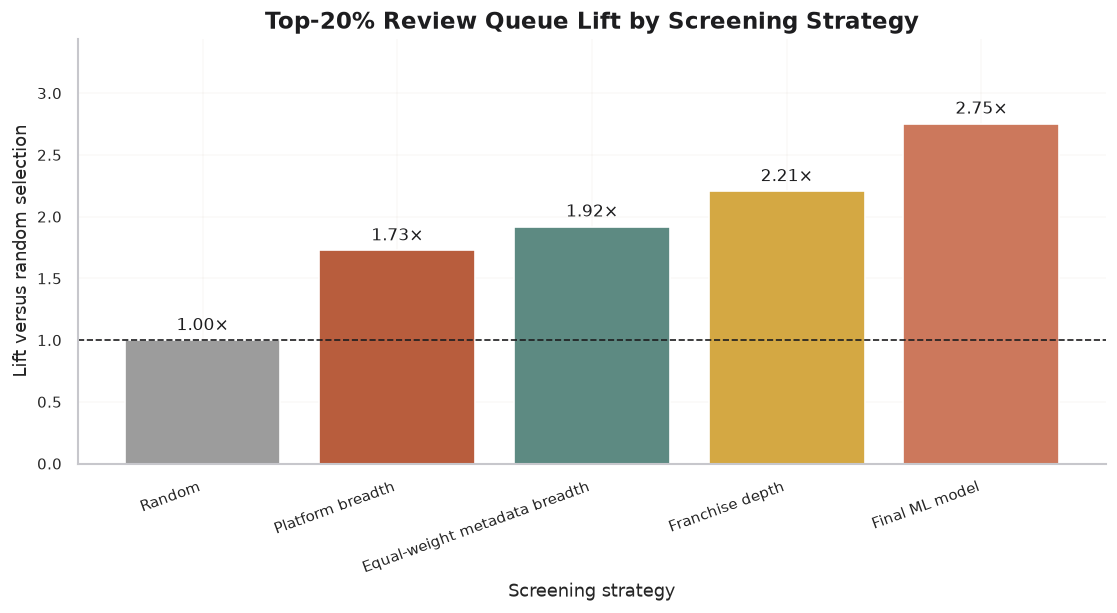

In [18]:
# Business visualisation: compare stage-matched strategies at the same review capacity.
top20_lift_rows = heuristic_benchmark_lift[
    heuristic_benchmark_lift["screening_group"].eq("Top 20% predicted")
].copy()
lift_plot = (
    top20_lift_rows[["method", "lift_vs_random"]]
    .drop_duplicates(subset=["method"])
    .sort_values("lift_vs_random")
    .reset_index(drop=True)
)
lift_plot = pd.concat([
    pd.DataFrame([{"method": "Random", "lift_vs_random": 1.0}]),
    lift_plot,
], ignore_index=True)

strategy_colors = {
    "Random": PALETTE[6],
    "Platform breadth": PALETTE[1],
    "Franchise depth": PALETTE[4],
    "Equal-weight metadata breadth": PALETTE[5],
    "Final ML model": PALETTE[0],
    "Random review": PALETTE[6],
    "Best simple heuristic": PALETTE[4],
}

fig, ax = plt.subplots(figsize=FIG_WIDE, constrained_layout=True)
bars = ax.bar(
    lift_plot["method"], lift_plot["lift_vs_random"],
    color=[strategy_colors[method] for method in lift_plot["method"]],
)
ax.axhline(1.0, linestyle="--", linewidth=1, color=INK)
ax.set_title("Top-20% Review Queue Lift by Screening Strategy")
ax.set_xlabel("Screening strategy")
ax.set_ylabel("Lift versus random selection")
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.05, f"{height:.2f}×", ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, max(lift_plot["lift_vs_random"]) * 1.25)
ax.tick_params(axis="x", rotation=20)
for label in ax.get_xticklabels():
    label.set_ha("right")
save_multi(fig, "heuristic_vs_ml_lift")
plt.show()


### Interpretation: Lift Comparison

The final ML model achieves the strongest top-20% lift, but the franchise-depth rule is already useful. The incremental value therefore comes from combining signals rather than discovering that simple business judgement has no value. Distinct colours separate random, heuristic and ML strategies; all bars use the identical capacity and tie policy.


### Capacity-Aligned Error Analysis

The studio is assumed to review **20% of the 3,000 holdout games**, fixing the queue at **600 titles**. A false review is a selected game below the engagement threshold and consumes analyst time. A missed opportunity is a genuinely high-engagement comparable outside the queue. Defining errors at the actual capacity cutoff avoids imposing an arbitrary probability threshold unrelated to the business process.


In [19]:
# Capacity-aligned error examples
review_capacity = 0.20
games_to_review = int(np.ceil(len(y_holdout) * review_capacity))

holdout_screening = df.loc[holdout_index, [
    "title", "release_year", "all_genres", "all_platforms",
    "available_stores", "platform_count", "game_series_count",
    "engagement_score",
]].copy()
holdout_screening["actual_high_engagement"] = y_holdout
holdout_screening["model_priority_score"] = holdout_prob
holdout_screening["selected_for_review"] = False
selected_model_index = select_top_k(
    holdout_screening.index,
    holdout_screening["model_priority_score"],
    games_to_review,
)
holdout_screening.loc[selected_model_index, "selected_for_review"] = True

false_reviews = (
    holdout_screening[
        holdout_screening["selected_for_review"]
        & holdout_screening["actual_high_engagement"].eq(0)
    ]
    .nlargest(10, "model_priority_score")
    .assign(error_type="false_review")
)
missed_high_engagement = (
    holdout_screening[
        ~holdout_screening["selected_for_review"]
        & holdout_screening["actual_high_engagement"].eq(1)
    ]
    .nlargest(10, "engagement_score")
    .assign(error_type="missed_high_engagement")
)
top20_screening_errors = pd.concat(
    [false_reviews, missed_high_engagement], axis=0
).reset_index(names="source_index")
display_wrapped_table(top20_screening_errors, caption="Examples of high-priority review burden cases", hide_index=True)
top20_screening_errors.to_csv(
    OUTPUT_DIR / "top20_screening_errors.csv", index=False
)


source_index,title,release_year,all_genres,all_platforms,available_stores,platform_count,game_series_count,engagement_score,actual_high_engagement,model_priority_score,selected_for_review,error_type
2934,WipEout HD,2008.000000,Action|Racing|Arcade,PlayStation 3,PlayStation Store,1.000000,8.000000,3.020000,0,0.918504,True,false_review
10386,Magna Carta,2004.000000,RPG,PlayStation 2|PSP,Unknown,2.000000,2.000000,2.950000,0,0.902260,True,false_review
7728,SIREN,2004.000000,Adventure,PlayStation 4|PlayStation 2,PlayStation Store,2.000000,2.000000,3.790000,0,0.895348,True,false_review
9596,Madden NFL 07,2006.000000,Sports,Xbox|GameCube|Game Boy Advance|PlayStation 2|Wii|Xbox 360|PC,Nintendo Store|Xbox 360 Store,7.000000,19.000000,3.740000,0,0.888796,True,false_review
6295,Fist of The North Star: Lost Paradise,2018.000000,Action|Adventure,PlayStation 4|PlayStation 5,PlayStation Store,2.000000,12.000000,2.710000,0,0.878148,True,false_review
6135,Hard Corps: Uprising,2011.000000,Action|Shooter|Arcade|Platformer,Xbox 360|PlayStation 3,PlayStation Store|Xbox 360 Store,2.000000,11.000000,2.380000,0,0.869301,True,false_review
12988,Sentimental Graffiti: Yakusoku,2001.000000,Adventure|Simulation,Dreamcast|PlayStation,PlayStation Store,2.000000,1.000000,0.250000,0,0.861801,True,false_review
5392,Hydrophobia,2010.000000,Action|Shooter|Adventure,Xbox 360,Xbox Store|Xbox 360 Store,1.000000,1.000000,3.050000,0,0.859996,True,false_review
5835,Madden NFL 17,2016.000000,Sports,PlayStation 3|Xbox One|PlayStation 4|Xbox 360,PlayStation Store|Xbox 360 Store|Xbox Store,4.000000,19.000000,4.100000,0,0.846260,True,false_review
2160,KILLER IS DEAD,2013.000000,Action|Adventure,Xbox 360|PC|Xbox One|PlayStation 3,PlayStation Store|Xbox Store|Xbox 360 Store,4.000000,0.000000,3.920000,0,0.842098,True,false_review


### Decision Simulation

Random review is expressed as its expected yield, while the training-selected simple rule and final model use realised holdout rankings. Each strategy receives the same 600-game analyst budget, making additional positives found, false-review burden and missed opportunities directly comparable.


In [20]:
# Equal-capacity decision simulation
total_holdout_positives = int(y_holdout.sum())
holdout_base_rate = float(y_holdout.mean())
random_expected_found = games_to_review * holdout_base_rate


def realised_decision_row(review_strategy, score):
    score = pd.Series(score, index=getattr(score, "index", y_holdout.index)).reindex(y_holdout.index)
    selected_index = select_top_k(y_holdout.index, score, games_to_review)
    positives_found = int(y_holdout.loc[selected_index].sum())
    return {
        "review_strategy": review_strategy,
        "games_reviewed": games_to_review,
        "high_engagement_games_found": positives_found,
        "additional_found_vs_random": positives_found - random_expected_found,
        "false_review_burden": games_to_review - positives_found,
        "missed_high_engagement_games": total_holdout_positives - positives_found,
    }


decision_rows = [{
    "review_strategy": "Random expected screening",
    "games_reviewed": games_to_review,
    "high_engagement_games_found": random_expected_found,
    "additional_found_vs_random": 0.0,
    "false_review_burden": games_to_review - random_expected_found,
    "missed_high_engagement_games": total_holdout_positives - random_expected_found,
}]
decision_rows.append(realised_decision_row(
    "Training-selected simple heuristic",
    holdout_heuristic_scores[selected_heuristic_name],
))
decision_rows.append(realised_decision_row(
    "Final ML model",
    pd.Series(holdout_prob, index=holdout_index),
))

decision_simulation = pd.DataFrame(decision_rows)
decision_simulation["business_interpretation"] = [
    "Expected baseline with no prioritisation.",
    f"Simple stage-matched rule selected on training data: {selected_heuristic_name}.",
    "Model-supported queue for human comparable-game review.",
]
display_wrapped_table(decision_simulation, caption="Decision simulation under fixed review capacity", hide_index=True)
decision_simulation.to_csv(OUTPUT_DIR / "decision_simulation.csv", index=False)


review_strategy,games_reviewed,high_engagement_games_found,additional_found_vs_random,false_review_burden,missed_high_engagement_games,business_interpretation
Random expected screening,600,150.000000,0.000000,450.000000,600.000000,Expected baseline with no prioritisation.
Training-selected simple heuristic,600,331.000000,181.000000,269.000000,419.000000,Simple stage-matched rule selected on training data: Franchise depth.
Final ML model,600,413.000000,263.000000,187.000000,337.000000,Model-supported queue for human comparable-game review.


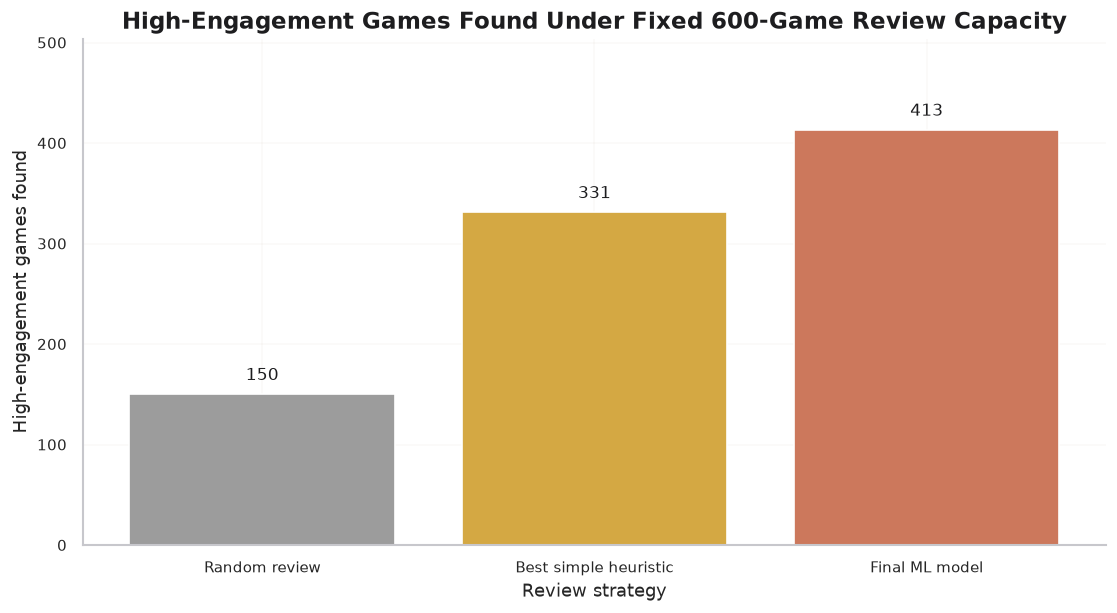

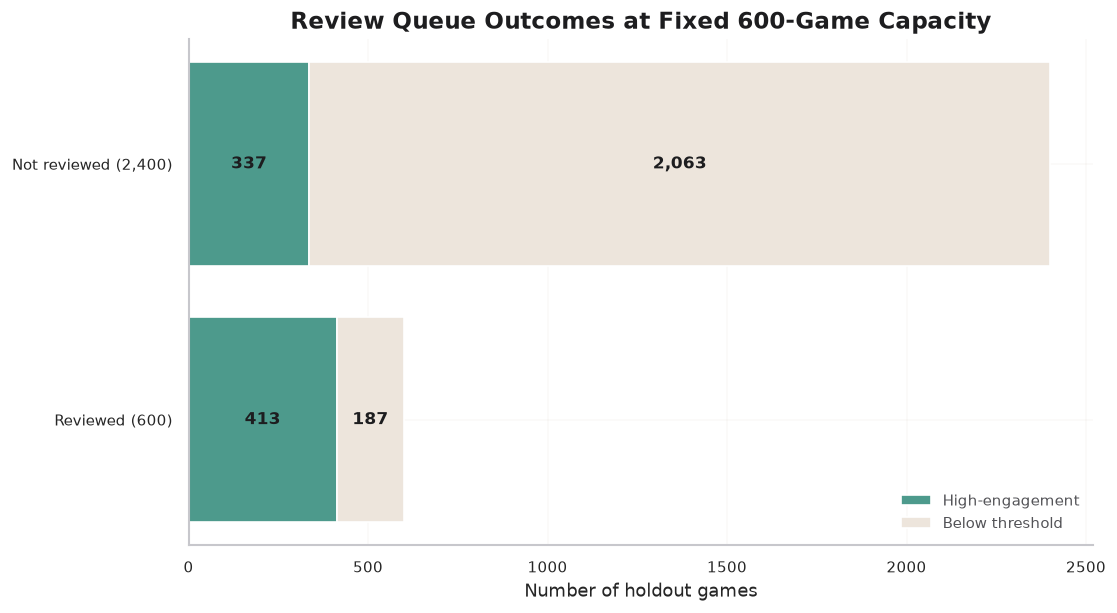

In [21]:
# Business visualisation: translate model performance into analyst workload.
decision_plot = decision_simulation.copy()
decision_plot["high_engagement_games_found"] = decision_plot["high_engagement_games_found"].astype(float)
decision_plot["review_strategy_short"] = decision_plot["review_strategy"].replace({
    "Random expected screening": "Random review",
    "Training-selected simple heuristic": "Best simple heuristic",
    "Final ML model": "Final ML model",
})

fig, ax = plt.subplots(figsize=FIG_WIDE, constrained_layout=True)
bars = ax.bar(
    decision_plot["review_strategy_short"],
    decision_plot["high_engagement_games_found"],
    color=[strategy_colors[name] for name in decision_plot["review_strategy_short"]],
)
ax.set_title("High-Engagement Games Found Under Fixed 600-Game Review Capacity")
ax.set_xlabel("Review strategy")
ax.set_ylabel("High-engagement games found")
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + max(decision_plot["high_engagement_games_found"]) * 0.025, f"{height:.0f}", ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, max(decision_plot["high_engagement_games_found"]) * 1.22)
save_multi(fig, "decision_simulation_bar_chart")
plt.show()


# Capacity-outcome view: reviewed/not-reviewed are mutually exclusive segments.
model_decision_row = decision_simulation.loc[
    decision_simulation["review_strategy"].eq("Final ML model")
].iloc[0]
captured = int(model_decision_row["high_engagement_games_found"])
false_review = int(model_decision_row["false_review_burden"])
missed = int(model_decision_row["missed_high_engagement_games"])
not_reviewed_non_high = len(y_holdout) - games_to_review - missed
queue_outcomes = pd.DataFrame({
    "portfolio_segment": [f"Reviewed ({games_to_review:,})", f"Not reviewed ({len(y_holdout) - games_to_review:,})"],
    "High-engagement": [captured, missed],
    "Below threshold": [false_review, not_reviewed_non_high],
})

fig, ax = plt.subplots(figsize=FIG_WIDE, constrained_layout=True)
left = np.zeros(len(queue_outcomes))
outcome_colors = {"High-engagement": PALETTE[2], "Below threshold": PALETTE[7]}
for outcome in ["High-engagement", "Below threshold"]:
    values = queue_outcomes[outcome].to_numpy()
    bars = ax.barh(queue_outcomes["portfolio_segment"], values, left=left, color=outcome_colors[outcome], label=outcome)
    for bar, value in zip(bars, values):
        if value >= 100:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2, f"{int(value):,}", ha="center", va="center", fontsize=10, fontweight="bold")
    left += values
ax.set_title("Review Queue Outcomes at Fixed 600-Game Capacity")
ax.set_xlabel("Number of holdout games")
ax.legend(loc="lower right")
save_multi(fig, "review_queue_outcomes", "review_queue_funnel")
# Legacy filename retained for downstream report compatibility; content is the corrected outcome view.
plt.show()


### Interpretation: Decision Simulation and Capacity Outcomes

Under the same 600-game review capacity, random review is expected to identify **150** high-engagement games, the training-selected franchise-depth heuristic identifies **331**, and the final ML model identifies **413**. The ML queue therefore adds **82** finds over the simple rule and **263** over random expectation without increasing analyst workload.

The stacked outcome view is not a sequential funnel. It partitions the holdout into mutually exclusive **reviewed** and **not reviewed** groups, then shows high-engagement and below-threshold outcomes inside each. This makes the model's **413 captured positives**, **187 false reviews**, **337 missed positives** and **2,063 unreviewed below-threshold games** arithmetically coherent while preserving the human-review boundary.


In [22]:
# Score-decile ranking diagnostic (not calibration)
decile_frame = pd.DataFrame({
    "y_true": np.asarray(y_holdout, dtype=int),
    "model_priority_score": np.asarray(holdout_prob, dtype=float),
}, index=y_holdout.index)
ordered_ids = select_top_k(
    decile_frame.index,
    decile_frame["model_priority_score"],
    len(decile_frame),
)
decile_number = np.floor(np.arange(len(ordered_ids)) * 10 / len(ordered_ids)).astype(int) + 1
decile_frame["score_decile"] = pd.Series(decile_number, index=ordered_ids)
decile_ranking_table = (
    decile_frame.groupby("score_decile", as_index=False)
    .agg(
        number_of_games=("y_true", "size"),
        mean_model_priority_score=("model_priority_score", "mean"),
        actual_high_engagement_rate=("y_true", "mean"),
        actual_high_engagement_count=("y_true", "sum"),
    )
    .sort_values("score_decile")
    .reset_index(drop=True)
)
display(decile_ranking_table.style.format({
    "mean_model_priority_score": "{:.1%}",
    "actual_high_engagement_rate": "{:.1%}",
}))
decile_ranking_table.to_csv(OUTPUT_DIR / "decile_ranking_table.csv", index=False)
# Legacy alias retained for compatibility with the earlier report/test contract.
decile_ranking_table.to_csv(OUTPUT_DIR / "decile_calibration_table.csv", index=False)
decile_ranking_table.to_csv(OUTPUT_DIR / "rebuild_decile_calibration_table.csv", index=False)


,score_decile,number_of_games,mean_model_priority_score,actual_high_engagement_rate,actual_high_engagement_count
0,1,300,83.4%,85.3%,256
1,2,300,67.2%,52.3%,157
2,3,300,54.8%,34.7%,104
3,4,300,48.0%,33.3%,100
4,5,300,42.0%,20.7%,62
5,6,300,36.5%,11.7%,35
6,7,300,30.0%,7.0%,21
7,8,300,21.2%,4.0%,12
8,9,300,11.9%,1.0%,3
9,10,300,4.2%,0.0%,0


### Evidence-led interpretation

**Analytical question.** Does ML improve the review queue enough to justify its complexity, and where does it still fail?

**Numerical evidence.** Random review of 600 games is expected to find **150 positives**. The training-selected franchise-depth heuristic finds **331** under the shared deterministic tie policy, while the ML queue finds **413**: **82 more than the heuristic** and **263 above random expectation**. The ML queue contains **187 false reviews** and leaves **337 high-engagement games outside the queue**. The score-decile diagnostic supports ordering quality: the top decile contains **256 positives (85.3%)**, whereas the bottom decile contains **zero**.

**Judgement.** ML creates incremental prioritisation value beyond a plausible simple rule, but it does not eliminate opportunity risk. The 337 misses are too consequential for a greenlight or rejection system.

**Alternative explanation.** Results depend on this capacity, target definition and historical snapshot. Future market composition can change realised yields even though row-order ties are now deterministic.

**Decision consequence.** Deploy, at most, a model-assisted review queue with producer override and periodic error audits; never treat exclusion from the top 20% as evidence that a concept lacks potential.

### Business interpretation of the review queue

The strongest business evidence is not the ROC-AUC score alone, but the decision simulation under fixed analyst capacity. In a 600-game review queue, random screening would identify about 150 high-engagement games, the training-selected franchise-depth heuristic identifies 331, and the final ML model identifies 413. This means the model adds 263 more high-engagement comparables than random review and 82 more than the best simple rule, without increasing analyst workload. The remaining 337 missed positives show why the model should support, not replace, human judgement.


---
## 11. Platform Ablation

The paired ablation holds rows, folds, estimator and non-platform features constant. Platform contribution is judged against a pre-declared practical rule: **Delta AUC must be at least 0.01 and its paired interval must remain above zero**. This separates a detectable change from one large enough to influence the feature-set decision.


In [23]:
# Platform ablation with matched folds
with_spec = feature_sets["A_design_distribution_screening"]
without_spec = feature_sets["A_no_platform_ablation"]

# Remove platform signals while holding folds and model family constant.
paired_fold_rows = []
for fold, (fit_pos, valid_pos) in enumerate(cv.split(X_train_main, y_train), start=1):
    fold_train_index = train_index[fit_pos]
    fold_valid_index = train_index[valid_pos]
    fold_y_train = df.loc[fold_train_index, "high_engagement"]
    fold_y_valid = df.loc[fold_valid_index, "high_engagement"]
    fold_scores = {}
    for label, spec in [("with_platform", with_spec), ("without_platform", without_spec)]:
        cols = spec["numeric"] + spec["categorical"] + spec["texts"]
        pipe = build_pipeline(spec, best_model_name)
        pipe.fit(df.loc[fold_train_index, cols], fold_y_train)
        prob = pipe.predict_proba(df.loc[fold_valid_index, cols])[:, 1]
        fold_scores[label] = roc_auc_score(fold_y_valid, prob)
    paired_fold_rows.append({"fold": fold, **fold_scores, "auc_delta": fold_scores["with_platform"] - fold_scores["without_platform"]})
paired_folds = pd.DataFrame(paired_fold_rows)

without_columns = without_spec["numeric"] + without_spec["categorical"] + without_spec["texts"]
without_pipeline = build_pipeline(without_spec, best_model_name)
without_pipeline.fit(df.loc[train_index, without_columns], y_train)
without_prob = without_pipeline.predict_proba(df.loc[holdout_index, without_columns])[:, 1]
auc_with = holdout_values["roc_auc"]
auc_without = roc_auc_score(y_holdout, without_prob)
auc_delta = auc_with - auc_without

delta_boot = []
local_rng = np.random.default_rng(RANDOM_STATE)
y_arr = y_holdout.to_numpy()
for _ in range(1000):
    idx = local_rng.integers(0, len(y_arr), len(y_arr))
    if np.unique(y_arr[idx]).size < 2:
        continue
    delta_boot.append(roc_auc_score(y_arr[idx], holdout_prob[idx]) - roc_auc_score(y_arr[idx], without_prob[idx]))
delta_ci = np.quantile(delta_boot, [.025, .975])
practical_threshold = 0.01
cv_delta = paired_folds["auc_delta"].mean()
holdout_clears_rule = auc_delta >= practical_threshold and delta_ci[0] > 0
cv_clears_rule = cv_delta >= practical_threshold
if holdout_clears_rule and cv_clears_rule:
    practical_conclusion = "consistent practically meaningful incremental signal"
elif holdout_clears_rule != cv_clears_rule:
    practical_conclusion = "mixed evidence: holdout and training CV do not agree on practical magnitude"
elif abs(auc_delta) < practical_threshold and abs(cv_delta) < practical_threshold:
    practical_conclusion = "consistently small incremental signal below the practical threshold"
else:
    practical_conclusion = "uncertain incremental signal"

platform_model_ablation = pd.DataFrame([{
    "model": best_model_name,
    "training_cv_auc_with_mean": paired_folds["with_platform"].mean(),
    "training_cv_auc_without_mean": paired_folds["without_platform"].mean(),
    "training_cv_paired_delta_mean": paired_folds["auc_delta"].mean(),
    "training_cv_paired_delta_sd": paired_folds["auc_delta"].std(ddof=1),
    "holdout_auc_with": auc_with, "holdout_auc_without": auc_without,
    "holdout_auc_delta": auc_delta, "holdout_delta_ci_low": delta_ci[0], "holdout_delta_ci_high": delta_ci[1],
    "practical_threshold": practical_threshold, "conclusion": practical_conclusion,
}])
display_wrapped_table(paired_folds, caption="Paired CV folds for platform ablation", hide_index=True)
display_wrapped_table(platform_model_ablation, caption="Platform ablation summary", hide_index=True)
platform_model_ablation.to_csv(OUTPUT_DIR / "rebuild_platform_model_ablation.csv", index=False)
platform_model_ablation.to_csv(OUTPUT_DIR / "platform_ablation_metrics.csv", index=False)


fold,with_platform,without_platform,auc_delta
1,0.857741,0.855220,0.002521
2,0.856323,0.850913,0.005411
3,0.860782,0.851423,0.009359
4,0.864150,0.866025,-0.001875
5,0.853830,0.852282,0.001547


model,training_cv_auc_with_mean,training_cv_auc_without_mean,training_cv_paired_delta_mean,training_cv_paired_delta_sd,holdout_auc_with,holdout_auc_without,holdout_auc_delta,holdout_delta_ci_low,holdout_delta_ci_high,practical_threshold,conclusion
RandomForest_flexible,0.858565,0.855173,0.003393,0.004230,0.868671,0.857197,0.011474,0.003933,0.019649,0.010000,mixed evidence: holdout and training CV do not agree on practical magnitude


### Evidence-led interpretation

**Analytical question.** How much incremental predictive information remains after platform variables are removed from an otherwise matched model?

**Numerical evidence.** In training CV, AUC is **0.8586 with platform evidence** and **0.8552 without it**, a mean paired gain of only **0.0034 (SD 0.0042)**, below the 0.01 practical threshold. On the holdout, AUC is **0.8687 versus 0.8572**, producing **Delta AUC +0.0115** with bootstrap **95% CI +0.0039 to +0.0196**.

**Judgement.** This is **mixed evidence**: the holdout clears the pre-declared rule, while the training-CV mean does not. Platform information remains useful context, but its incremental magnitude is not stable enough to support a strong standalone claim.

**Alternative explanation.** Platform coverage can proxy budget, publisher reach, prior success and later porting. Predictive ablation cannot estimate the commercial return from adding a platform.

**Decision consequence.** Retain platform information for screening, but require separate audience, cost and timing evidence for porting decisions and monitor whether its incremental value persists after refresh.


---
## 12. Chronological Sensitivity

A secondary evaluation trains on the oldest 80% of dated releases and evaluates the newest 20%, using the strict boundary **2021-07-21 < 2021-07-22**. This is not a clean causal forecast because recent games have had less exposure time to accumulate the snapshot proxy. Its purpose is to reveal how much a random split may conceal temporal fragility.


In [24]:
# Chronological sensitivity to temporal drift
chronological = df.sort_values(["release_date_parsed", "game_id"]).copy()
date_counts = chronological.groupby("release_date_parsed").size().sort_index()
cutoff_date = date_counts.cumsum().ge(len(chronological) * .80).idxmax()
chrono_train = chronological.loc[chronological["release_date_parsed"] < cutoff_date]
chrono_test = chronological.loc[chronological["release_date_parsed"] >= cutoff_date]
assert chrono_train["release_date_parsed"].max() < chrono_test["release_date_parsed"].min()
chrono_pipeline = build_pipeline(best_spec, best_model_name)
chrono_pipeline.fit(chrono_train[main_columns], chrono_train["high_engagement"])
chrono_prob = chrono_pipeline.predict_proba(chrono_test[main_columns])[:, 1]
chrono_pred = chrono_pipeline.predict(chrono_test[main_columns])
chronological_sensitivity = pd.DataFrame([{
    "model": best_model_name,
    "train_end_date": chrono_train["release_date_parsed"].max().date(),
    "test_start_date": chrono_test["release_date_parsed"].min().date(),
    "train_rows": len(chrono_train), "test_rows": len(chrono_test),
    "train_positive_rate": chrono_train["high_engagement"].mean(),
    "test_positive_rate": chrono_test["high_engagement"].mean(),
    "roc_auc": roc_auc_score(chrono_test["high_engagement"], chrono_prob),
    "pr_auc": average_precision_score(chrono_test["high_engagement"], chrono_prob),
    "f1": f1_score(chrono_test["high_engagement"], chrono_pred, zero_division=0),
    "balanced_accuracy": balanced_accuracy_score(chrono_test["high_engagement"], chrono_pred),
}])
display(chronological_sensitivity)
chronological_sensitivity.to_csv(OUTPUT_DIR / "rebuild_chronological_sensitivity.csv", index=False)
chronological_sensitivity.to_csv(OUTPUT_DIR / "chronological_sensitivity_metrics.csv", index=False)

chrono_row = chronological_sensitivity.iloc[0]

,model,train_end_date,test_start_date,train_rows,test_rows,train_positive_rate,test_positive_rate,roc_auc,pr_auc,f1,balanced_accuracy
0,RandomForest_flexible,2021-07-21,2021-07-22,11999,3001,0.239103,0.294235,0.685583,0.505037,0.403446,0.605056


### Evidence-led interpretation

**Analytical question.** Does performance remain credible when the model must rank later releases rather than a random historical mixture?

**Numerical evidence.** ROC AUC falls from **0.869** on the random holdout to **0.686** chronologically, a decline of approximately **0.183**. Chronological PR AUC is **0.505**, F1 is **0.403** and balanced accuracy is **0.605**. Positive prevalence also shifts from **23.9% in training** to **29.4% in the newest test period**.

**Judgement.** The model retains some out-of-time discrimination but is materially less reliable on later releases. The random holdout is therefore evidence of within-snapshot ranking, not permanent forecasting performance.

**Alternative explanation.** The decline can reflect genuine concept drift, different documentation and platform patterns, or shorter accumulation windows for recent titles. The current data cannot isolate those mechanisms.

**Decision consequence.** Treat the model as a current-market screening aid. Collect time-stamped outcomes, monitor prevalence and ranking drift, and recalibrate before any operational deployment.


---
## 13. Feature Importance and Explainability

Raw-input permutation importance measures the holdout AUC loss after one source field is shuffled. Grouped permutation shuffles related fields together, avoiding the invalid practice of summing unequal numbers of transformed features. SHAP then shows how transformed inputs contribute across sampled holdout predictions. All three methods explain fitted-model reliance; none identifies a causal effect.


feature,importance_mean_auc_drop,importance_sd,business_theme,importance_method
platform_text,0.102969,0.006825,platform_and_distribution,holdout_raw_feature_permutation_auc
design_text,0.073586,0.005162,text_and_tag_language,holdout_raw_feature_permutation_auc
game_series_count,0.008948,0.001026,franchise_and_release,holdout_raw_feature_permutation_auc
decade,0.005388,0.001088,franchise_and_release,holdout_raw_feature_permutation_auc
release_year,0.003465,0.000597,franchise_and_release,holdout_raw_feature_permutation_auc
achievements_count,0.003425,0.000247,design_metadata,holdout_raw_feature_permutation_auc
art_style,0.002178,0.000595,design_metadata,holdout_raw_feature_permutation_auc
controls,0.001989,0.000513,design_metadata,holdout_raw_feature_permutation_auc
theme,0.001435,0.000478,design_metadata,holdout_raw_feature_permutation_auc
esrb_rating,0.000875,0.000890,design_metadata,holdout_raw_feature_permutation_auc


business_theme,raw_columns_shuffled_together,mean_auc_drop,sd_auc_drop,importance_method
platform_and_distribution,platform_count | is_multi_platform | platform_text,0.115193,0.005469,grouped_holdout_permutation_auc
text_and_tag_language,design_text,0.075954,0.006947,grouped_holdout_permutation_auc
design_metadata,is_multiplayer | achievements_count | theme | art_style | view_dimension | game_mode | controls | esrb_rating,0.056537,0.004121,grouped_holdout_permutation_auc
franchise_and_release,game_series_count | release_year | decade,0.027447,0.002399,grouped_holdout_permutation_auc


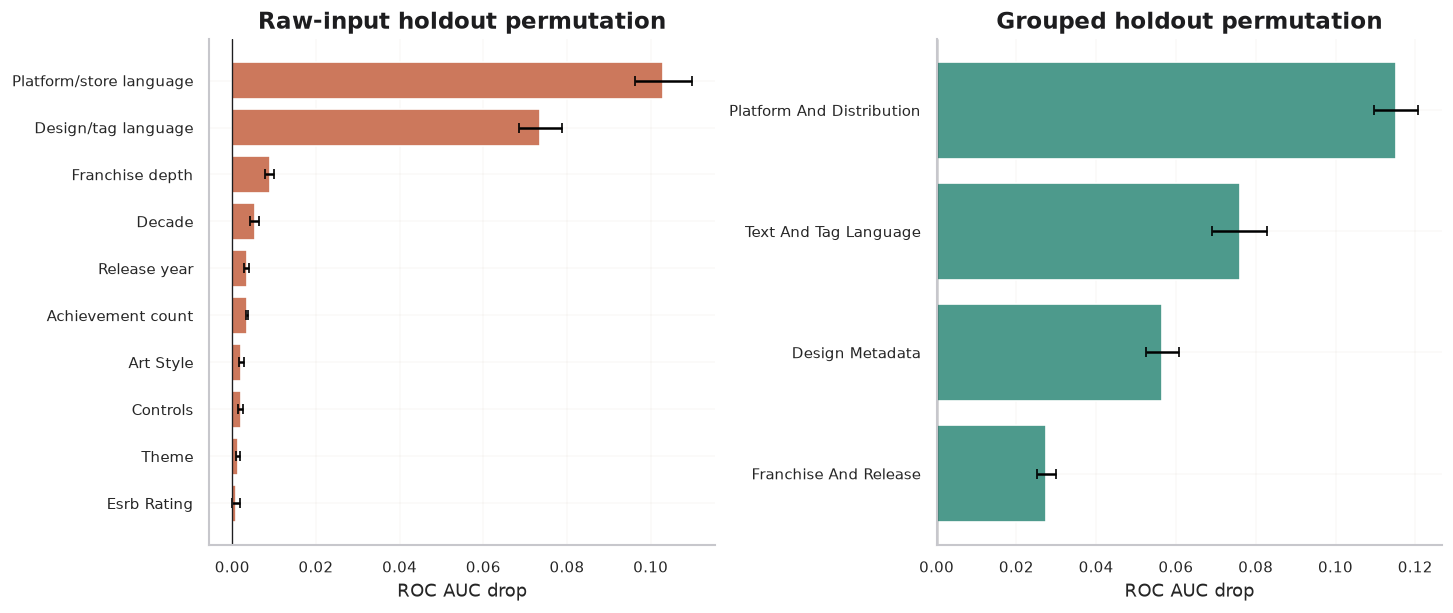

In [25]:
# Permutation importance and SHAP explanations
# Measure holdout importance first; SHAP then explains the fitted tree locally.
raw_permutation = permutation_importance(
    main_pipeline, X_holdout, y_holdout, scoring="roc_auc", n_repeats=8,
    random_state=RANDOM_STATE, n_jobs=1,
)
raw_theme_map = {
    "platform_count": "platform_and_distribution", "is_multi_platform": "platform_and_distribution", "platform_text": "platform_and_distribution",
    "release_year": "franchise_and_release", "decade": "franchise_and_release", "game_series_count": "franchise_and_release",
    "design_text": "text_and_tag_language",
    "user_rating": "postlaunch_visibility_or_quality", "metacritic": "postlaunch_visibility_or_quality", "ratings_count": "postlaunch_visibility_or_quality", "reviews_count": "postlaunch_visibility_or_quality", "avg_playtime_hours": "postlaunch_visibility_or_quality",
}
feature_importance = pd.DataFrame({
    "feature": main_columns,
    "importance_mean_auc_drop": raw_permutation.importances_mean,
    "importance_sd": raw_permutation.importances_std,
})
feature_importance["business_theme"] = feature_importance["feature"].map(raw_theme_map).fillna("design_metadata")
feature_importance["importance_method"] = "holdout_raw_feature_permutation_auc"
feature_importance = feature_importance.sort_values("importance_mean_auc_drop", ascending=False).reset_index(drop=True)
display_wrapped_table(feature_importance, caption="Raw permutation importance", hide_index=True)
feature_importance.to_csv(OUTPUT_DIR / "rebuild_feature_importance.csv", index=False)

raw_groups = {
    "platform_and_distribution": [c for c in ["platform_count", "is_multi_platform", "platform_text"] if c in main_columns],
    "franchise_and_release": [c for c in ["game_series_count", "release_year", "decade"] if c in main_columns],
    "design_metadata": [c for c in ["is_multiplayer", "achievements_count", "theme", "art_style", "view_dimension", "game_mode", "controls", "esrb_rating"] if c in main_columns],
    "text_and_tag_language": [c for c in ["design_text"] if c in main_columns],
}
baseline_auc = roc_auc_score(y_holdout, holdout_prob)
grouped_rows = []
group_rng = np.random.default_rng(RANDOM_STATE)
for theme, columns in raw_groups.items():
    drops = []
    for _ in range(12):
        shuffled = X_holdout.copy()
        permutation = group_rng.permutation(len(shuffled))
        for column in columns:
            shuffled[column] = shuffled[column].to_numpy()[permutation]
        shuffled_prob = main_pipeline.predict_proba(shuffled)[:, 1]
        drops.append(baseline_auc - roc_auc_score(y_holdout, shuffled_prob))
    grouped_rows.append({
        "business_theme": theme, "raw_columns_shuffled_together": " | ".join(columns),
        "mean_auc_drop": np.mean(drops), "sd_auc_drop": np.std(drops, ddof=1),
        "importance_method": "grouped_holdout_permutation_auc",
    })
theme_importance = pd.DataFrame(grouped_rows).sort_values("mean_auc_drop", ascending=False).reset_index(drop=True)
display_wrapped_table(theme_importance, caption="Grouped permutation importance by business theme", hide_index=True)
theme_importance.to_csv(OUTPUT_DIR / "rebuild_feature_theme_importance.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=FIG_DUAL, constrained_layout=True)
raw_display_labels = {
    "platform_text": "Platform/store language",
    "design_text": "Design/tag language",
    "game_series_count": "Franchise depth",
    "platform_count": "Platform breadth",
    "release_year": "Release year",
    "achievements_count": "Achievement count",
    "is_multi_platform": "Multi-platform indicator",
    "is_multiplayer": "Multiplayer indicator",
}
raw_plot = feature_importance.head(10).sort_values("importance_mean_auc_drop").copy()
raw_plot["display_feature"] = raw_plot["feature"].map(raw_display_labels).fillna(
    raw_plot["feature"].str.replace("_", " ").str.title()
)
axes[0].barh(raw_plot["display_feature"], raw_plot["importance_mean_auc_drop"], xerr=raw_plot["importance_sd"], color=PALETTE[0], capsize=3)
axes[0].axvline(0, color=INK, linewidth=.8)
axes[0].set(title="Raw-input holdout permutation", xlabel="ROC AUC drop", ylabel="")
theme_plot = theme_importance.sort_values("mean_auc_drop").copy()
theme_plot["display_theme"] = theme_plot["business_theme"].str.replace("_", " ").str.title()
axes[1].barh(theme_plot["display_theme"], theme_plot["mean_auc_drop"], xerr=theme_plot["sd_auc_drop"], color=PALETTE[2], capsize=3)
axes[1].axvline(0, color=INK, linewidth=.8)
axes[1].set(title="Grouped holdout permutation", xlabel="ROC AUC drop", ylabel="")
save_multi(fig, "rebuild_feature_importance", "feature_importance")
plt.show()


feature,display_feature,mean_abs_shap,mean_signed_shap,importance_method
num__game_series_count,Game Series Count,0.039134,-0.007759,directional_shap_on_holdout_sample
text_platform_text__steam,Platform/Store Term: Steam,0.027615,-0.003812,directional_shap_on_holdout_sample
text_platform_text__pc,Platform/Store Term: Pc,0.027578,-0.005381,directional_shap_on_holdout_sample
cat__decade_2010s,Decade: 2010S,0.017995,-0.002288,directional_shap_on_holdout_sample
text_design_text__indie,Design/Tag Term: Indie,0.016472,0.000143,directional_shap_on_holdout_sample
text_platform_text__playstation,Platform/Store Term: Playstation,0.016083,-0.001057,directional_shap_on_holdout_sample
text_design_text__story rich,Design/Tag Term: Story Rich,0.015814,-0.003796,directional_shap_on_holdout_sample
cat__esrb_rating_Not Rated,Esrb: Rating Not Rated,0.014268,-0.000900,directional_shap_on_holdout_sample
num__release_year,Release Year,0.013457,-0.004412,directional_shap_on_holdout_sample
text_design_text__indie singleplayer,Design/Tag Term: Indie Singleplayer,0.011388,0.000925,directional_shap_on_holdout_sample


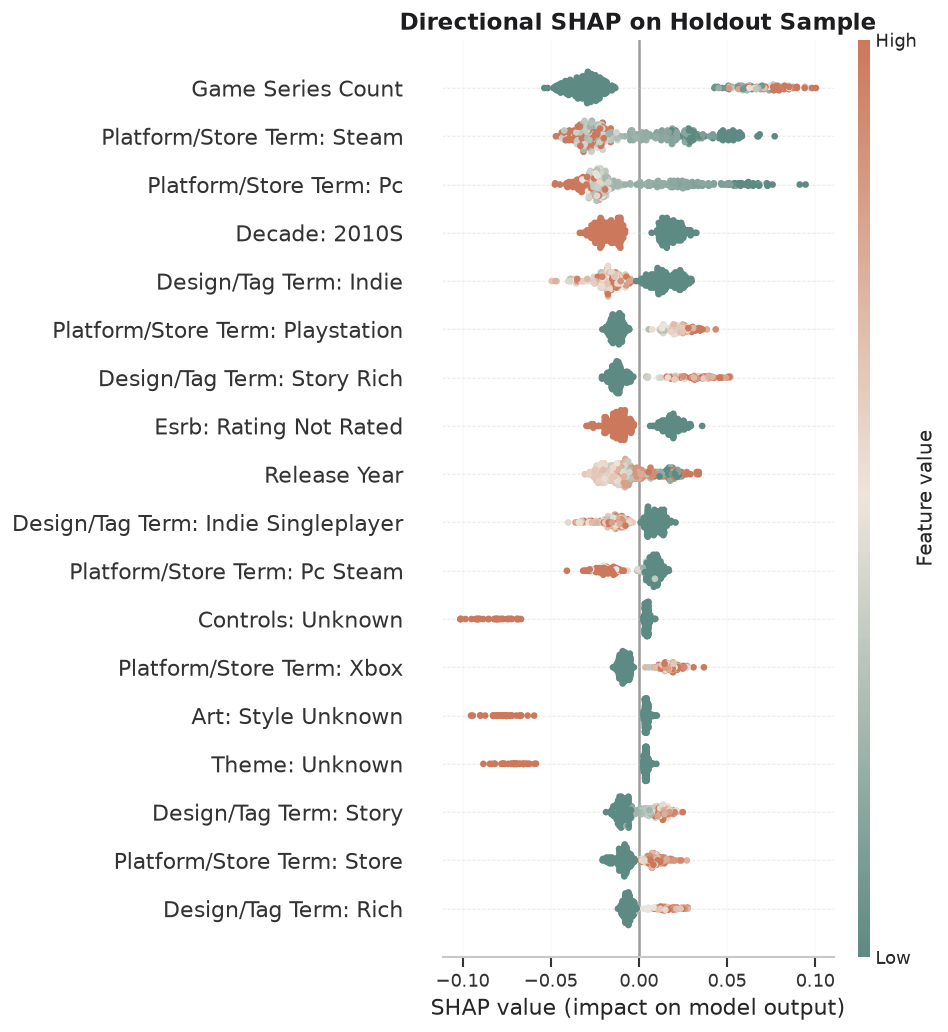

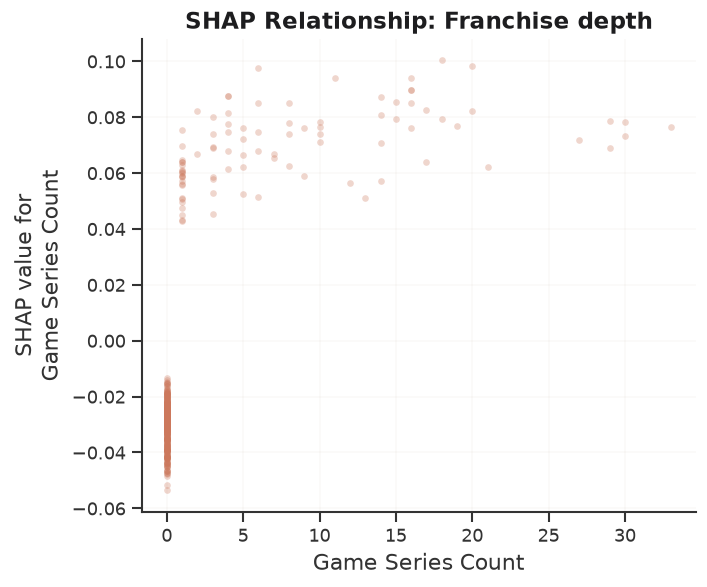

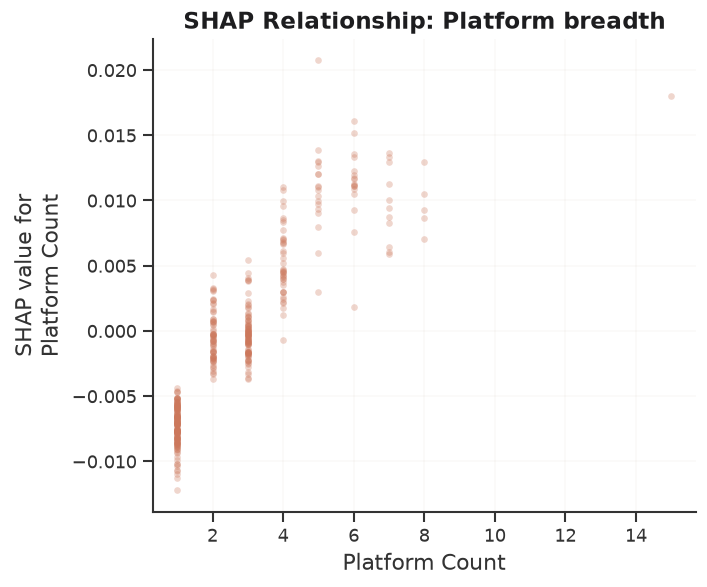

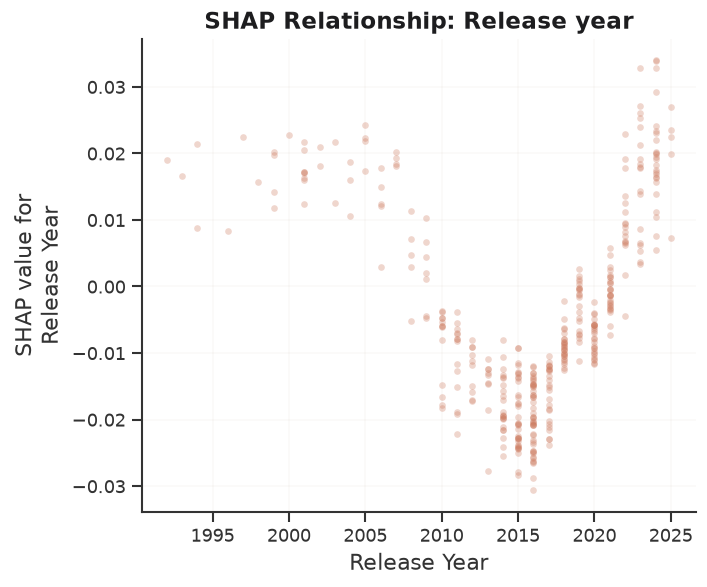

attempted,available,status,reason
True,True,success,"Directional SHAP, beeswarm and numeric dependence plots completed on holdout sample."


In [26]:
# SHAP execution with human-readable transformed-feature labels
def human_readable_feature_names(feature_names):
    """Convert pipeline feature names into concise business-facing SHAP labels."""
    labels = []
    for name in feature_names:
        label = str(name)
        if label.startswith("num__missingindicator_"):
            label = "Missing: " + label.removeprefix("num__missingindicator_").replace("_", " ")
        elif label.startswith("num__"):
            label = label.removeprefix("num__").replace("_", " ")
        elif label.startswith("cat__"):
            label = label.removeprefix("cat__").replace("_", ": ", 1).replace("_", " ")
        elif label.startswith("text_design_text__"):
            label = "Design/tag term: " + label.removeprefix("text_design_text__").replace("_", " ")
        elif label.startswith("text_platform_text__"):
            label = "Platform/store term: " + label.removeprefix("text_platform_text__").replace("_", " ")
        labels.append(label[:58].strip().title())
    return np.asarray(labels)


shap_status = {"attempted": False, "available": SHAP_AVAILABLE, "status": "not_attempted", "reason": ""}
shap_importance = pd.DataFrame()
try:
    fitted_preprocessor = main_pipeline.named_steps["preprocessor"]
    fitted_model = main_pipeline.named_steps["model"]
    if SHAP_AVAILABLE and (hasattr(fitted_model, "feature_importances_") or hasattr(fitted_model, "coef_")):
        shap_status["attempted"] = True
        shap_sample_raw = X_holdout.sample(min(400, len(X_holdout)), random_state=RANDOM_STATE)
        transformed_sample = fitted_preprocessor.transform(shap_sample_raw)
        transformed_dense = transformed_sample.toarray() if hasattr(transformed_sample, "toarray") else np.asarray(transformed_sample)
        transformed_feature_names = np.asarray(fitted_preprocessor.get_feature_names_out())
        shap_display_names = human_readable_feature_names(transformed_feature_names)

        if hasattr(fitted_model, "feature_importances_"):
            explainer = shap.TreeExplainer(fitted_model)
            shap_values = explainer.shap_values(transformed_dense)
        else:
            background_raw = X_train_main.sample(min(300, len(X_train_main)), random_state=RANDOM_STATE)
            background = fitted_preprocessor.transform(background_raw)
            background = background.toarray() if hasattr(background, "toarray") else np.asarray(background)
            explainer = shap.LinearExplainer(fitted_model, background)
            shap_values = explainer.shap_values(transformed_dense)

        if isinstance(shap_values, list):
            shap_array = np.asarray(shap_values[1])
        else:
            shap_array = np.asarray(shap_values)
            if shap_array.ndim == 3:
                shap_array = shap_array[:, :, 1]

        shap_importance = pd.DataFrame({
            "feature": transformed_feature_names,
            "display_feature": shap_display_names,
            "mean_abs_shap": np.abs(shap_array).mean(axis=0),
            "mean_signed_shap": shap_array.mean(axis=0),
            "importance_method": "directional_shap_on_holdout_sample",
        }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
        display_wrapped_table(shap_importance.head(25), caption="Top SHAP features", hide_index=True)
        shap_importance.to_csv(OUTPUT_DIR / "rebuild_shap_importance.csv", index=False)

        shap.summary_plot(shap_array, transformed_dense, feature_names=shap_display_names, max_display=18, show=False,
                          cmap=matplotlib.colors.LinearSegmentedColormap.from_list(
                              "warm_shap", [PALETTE[5], PALETTE[7], PALETTE[0]]))
        plt.title("Directional SHAP on Holdout Sample")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "rebuild_shap_beeswarm.png")
        plt.savefig(FIGURE_DIR / "shap_summary.png")
        plt.show()

        numeric_titles = {
            "game_series_count": "Franchise depth",
            "platform_count": "Platform breadth",
            "release_year": "Release year",
        }
        for raw_feature, display_name in numeric_titles.items():
            transformed_name = f"num__{raw_feature}"
            if transformed_name in transformed_feature_names:
                feature_position = int(np.flatnonzero(transformed_feature_names == transformed_name)[0])
                shap.dependence_plot(
                    feature_position, shap_array, transformed_dense,
                    feature_names=shap_display_names, interaction_index=None, show=False,
                )
                # Recolour scatter dots to terracotta — Warm Editorial signature.
                _ax = plt.gca()
                for _coll in _ax.collections:
                    _coll.set_facecolor(PALETTE[0])
                    _coll.set_edgecolor(PALETTE[0])
                    _coll.set_alpha(0.30)
                plt.title(f"SHAP Relationship: {display_name}")
                plt.tight_layout()
                plt.savefig(FIGURE_DIR / f"rebuild_shap_dependence_{raw_feature}.png")
                plt.show()
        shap_status["status"] = "success"
        shap_status["reason"] = "Directional SHAP, beeswarm and numeric dependence plots completed on holdout sample."
    else:
        shap_status["reason"] = "Selected estimator has no supported tree/linear SHAP path."
except Exception as exc:
    shap_status["status"] = "failed_non_blocking"
    shap_status["reason"] = repr(exc)

shap_status_table = pd.DataFrame([shap_status])
display_wrapped_table(shap_status_table, caption="SHAP execution status", hide_index=True)
shap_status_table.to_csv(OUTPUT_DIR / "rebuild_shap_status.csv", index=False)

top_raw = feature_importance.iloc[0]
top_theme = theme_importance.iloc[0]


### Evidence-led interpretation

**Analytical question.** Which evidence groups drive the fitted ranking, and can their effects be translated into product actions?

**Numerical evidence.** Raw permutation produces AUC drops of **0.1030** for platform/store language, **0.0736** for design/tag language and **0.0089** for franchise depth. Grouped permutation ranks platform/distribution at **0.1152**, design text at **0.0760**, design metadata at **0.0565** and franchise/release context at **0.0274**. SHAP ranks the transformed **Franchise Depth** feature highest by mean absolute contribution (**0.0391**), followed by platform/store terms such as Steam and PC at approximately **0.0276** each.

**Judgement.** Ranking depends on a bundle of distribution, language, design and franchise context rather than one controllable lever. Grouped and raw results agree that text-derived platform and design information carries substantial predictive signal.

**Alternative explanation.** Correlated fields can substitute for one another under permutation, while token and Unknown effects may capture documentation coverage. Mean absolute SHAP magnitude describes model reliance but does not imply a uniform beneficial direction.

**Decision consequence.** Use importance to target investigation and stress tests, particularly for new IP, sparse metadata and unusual platform strategies; do not optimise individual tokens or features as if they caused engagement.

### Interpretation boundary for model explanations

Feature importance, SHAP summaries, and ablation results show which signals the model relies on for ranking games. They do not prove that changing those features would cause engagement to increase. For example, platform breadth, franchise depth, tags, descriptions, or release timing may reflect budget, publisher support, visibility, existing audience, or later porting decisions. These findings should therefore guide benchmarking questions and human review priorities, not direct causal design rules.


---
## 14. Claim–Evidence–Action Matrix

The matrix below is the audit trail for the final recommendations. Each claim is paired with a computed value, an explicit limitation, a business interpretation and a bounded action. This prevents the recommendations from drifting beyond what the analysis can support.


In [27]:
# Claim-evidence-action audit trail
claim_evidence = pd.DataFrame([
    {
        "claim_en": "The source schema is complete, but target provenance is incomplete.",
        "evidence_en": "15,000 rows x 43 mapped source columns; engagement formula/timestamp not documented locally.",
        "limitation_en": "Construct validity of engagement_score cannot be independently verified from local artefacts.",
        "business_action_en": "Use engagement as a screening proxy, never as revenue or retention.",
        "business_meaning_en": "The dataset supports market screening, but not direct commercial valuation.",
    },
    {
        "claim_en": "Platform breadth has a strong descriptive gradient but limited causal meaning.",
        "evidence_en": f"Median engagement {one_platform.median_engagement:.2f} (n={int(one_platform.games):,}) for one platform vs {six_plus.median_engagement:.2f} (n={int(six_plus.games):,}) for 6+; Spearman rho with reviews={platform_review_rho:.3f}.",
        "limitation_en": "Reverse causality, budget and later porting are unmeasured.",
        "business_action_en": "Plan platform breadth deliberately, but do not assume every additional port causes engagement.",
        "business_meaning_en": "Platform coverage can identify visible or well-resourced comparables.",
    },
    {
        "claim_en": "The stage-matched screening model is useful for prioritisation, not automatic approval.",
        "evidence_en": f"Training-CV top-20% lift={best_row['top20_lift_mean']:.3f} (SD {best_row['top20_lift_std']:.3f}); holdout ROC AUC={holdout_values['roc_auc']:.3f} (95% CI {auc_ci[0]:.3f}-{auc_ci[1]:.3f}).",
        "limitation_en": f"The final 600-game queue still contains {int(model_decision_row.false_review_burden)} below-threshold games and misses {int(model_decision_row.missed_high_engagement_games)} positives.",
        "business_action_en": "Use scores to queue expert review and scenario analysis.",
        "business_meaning_en": "Scores can reduce the search space for expert review.",
    },
    {
        "claim_en": "Platform evidence shows mixed incremental predictive value.",
        "evidence_en": f"Training-CV paired delta AUC={cv_delta:+.4f}; holdout paired delta AUC={auc_delta:+.4f}, 95% CI {delta_ci[0]:+.4f} to {delta_ci[1]:+.4f}.",
        "limitation_en": "Predictive ablation does not identify the return from adding a platform.",
        "business_action_en": "Treat platform as one planning input, not the whole positioning strategy.",
        "business_meaning_en": "Platform variables add context, but evidence about incremental magnitude is mixed.",
    },
    {
        "claim_en": "Franchise/release context and other metadata must be interpreted alongside platform signals.",
        "evidence_en": f"game_series_count raw AUC drop={feature_importance.set_index('feature').loc['game_series_count', 'importance_mean_auc_drop']:.4f}; release_year drop={feature_importance.set_index('feature').loc['release_year', 'importance_mean_auc_drop']:.4f}; SHAP ranks transformed features by model reliance.",
        "limitation_en": "Permutation and SHAP explain the fitted model; correlated features and Unknown-category signals may reflect documentation coverage.",
        "business_action_en": "Review franchise maturity, release timing, design and distribution jointly.",
        "business_meaning_en": "Engagement signals reflect a bundle of franchise, timing, design and distribution factors.",
    },
    {
        "claim_en": "Temporal stability is uncertain.",
        "evidence_en": f"Newest-20% chronological ROC AUC={chrono_row.roc_auc:.3f}; test positive rate={chrono_row.test_positive_rate:.1%}.",
        "limitation_en": "Recent games have had less time to accumulate the snapshot proxy.",
        "business_action_en": "Collect time-stamped outcomes and recalibrate before operational deployment.",
        "business_meaning_en": "Current-market patterns should not be assumed to remain permanent.",
    },
])
claim_evidence = claim_evidence[[
    "claim_en", "evidence_en", "business_meaning_en",
    "business_action_en", "limitation_en",
]]
display_claim_evidence_cards(claim_evidence)
claim_evidence.to_csv(OUTPUT_DIR / "rebuild_claim_evidence_table.csv", index=False)
claim_evidence.to_csv(OUTPUT_DIR / "claim_evidence_action_matrix.csv", index=False)


### Evidence-led interpretation

**Analytical question.** What should the studio do differently after considering the full evidence chain?

**Numerical evidence.** The model achieves **ROC AUC 0.869**, finds **413** high-engagement comparables within a 600-game queue and adds **82** finds over the training-selected heuristic. It still misses **337** positives; platform ablation supplies mixed evidence; and chronological AUC falls to **0.686**.

**Judgement.** The evidence supports assisted prioritisation, not automated investment decisions. Ranking value is real within the snapshot, while residual errors, temporal degradation and construct uncertainty remain commercially material.

**Alternative explanation.** Engagement patterns may reflect omitted budget, publisher, exposure and franchise effects. Better prediction does not resolve those causal ambiguities.

**Decision consequences.**

1. **Use the score as a review queue, not a greenlight rule.** Combine ranking with producer judgement, budget constraints, playtesting and audience research.
2. **Treat platform breadth as one planning input.** Assess staged porting through audience fit, cost and delivery capacity rather than the observed gradient alone.
3. **Stress-test new-IP and low-documentation cases.** Established-franchise and metadata signals may not transfer to genuinely novel concepts.
4. **Separate planning from post-launch monitoring.** Ratings, reviews and playtime are valuable diagnostic signals after launch, not proof that a plan will succeed.
5. **Build a deployment-quality data layer.** Collect time-stamped engagement, original launch platforms, marketing, price, budget, retention and financial outcomes before investment use.


---
## 15. Model Use Policy

| Item | Recommendation |
|---|---|
| Intended use | Prioritise comparable-game review under limited analyst capacity. |
| Primary users | Product strategy, marketing, and platform/distribution teams. |
| Output meaning | Ranking or priority score, not a calibrated probability of commercial success. |
| Not intended use | Automatic investment, greenlight, cancellation, or causal design decisions. |
| Required oversight | Human review is required before any business action. |
| Main risks | Proxy target, temporal drift, platform bias, post-launch signals, and non-causal interpretation. |

This policy translates the validation evidence into a safe operating boundary. The model can reduce the search space for expert review, but it cannot decide whether a game should be funded, cancelled or copied.


---
## 16. Limitations and Future Enhancements

- **Construct validity:** The formula and observation date for `engagement_score` are unavailable. It cannot be interpreted as revenue, retention or direct player value.
- **Association rather than causation:** Platform breadth, franchise depth and text may proxy budget, publisher reach, prior success or documentation quality.
- **Exposure and temporal bias:** Older games have had longer to accumulate reviews, libraries and ports; the chronological AUC decline from 0.869 to 0.686 demonstrates that this matters operationally.
- **Overlapping groups:** Multi-label genre rows are not independent, so genre differences remain descriptive.
- **Model uncertainty:** Cross-validation variation, bootstrap intervals, capacity errors and chronological sensitivity measure different uncertainties; none supplies causal identification.
- **Interpretability limits:** Permutation and SHAP explain this fitted pipeline. Correlation can redistribute importance, and magnitude does not establish a controllable direction.
- **Future evidence:** Add original launch-platform timing, development and marketing spend, price, time-stamped players, retention and financial outcomes; then validate on a genuinely later cohort.

Earlier exploratory clustering is excluded from the core analysis because it used `engagement_score` to form clusters and then profiled them with `high_engagement`, creating circular interpretation. Its best silhouette score was also weak at approximately **0.236**, providing little justification for retaining it as a decision method.


---
## 17. Verification Guardrails

The following checks verify dataset loading, 15,000-row retention, complete 43-field mapping, binary-target integrity, train/holdout and fold separation, leakage exclusions, training-only text fitting, strict chronology, equal model coverage, fixed seeds, populated report outputs and consistent decision capacity. These controls do not prove that the business conclusions are true; they establish that the reported analysis was executed as designed.


In [28]:
# Final verification guardrails
missing_lookup = missing_table.set_index("column")
required_output_names = [
    "data_quality_summary.csv", "model_holdout_metrics.csv", "screening_lift_table.csv",
    "decile_ranking_table.csv", "decile_calibration_table.csv", "platform_ablation_metrics.csv",
    "chronological_sensitivity_metrics.csv", "claim_evidence_action_matrix.csv",
    "final_model_feature_list.csv", "target_threshold_sensitivity.csv",
    "heuristic_benchmark_lift.csv", "top20_screening_errors.csv",
    "decision_simulation.csv",
]
required_figure_names = [
    "target_distribution.png", "eda_key_differences.png", "roc_curve.png",
    "precision_recall_curve.png", "feature_importance.png", "shap_summary.png",
    "heuristic_vs_ml_lift.png", "decision_simulation_bar_chart.png",
    "review_queue_outcomes.png",
]

cv_integrity = []
for fit_pos, valid_pos in cv.split(X_train_main, y_train):
    fit_ids = set(train_index[fit_pos])
    valid_ids = set(train_index[valid_pos])
    cv_integrity.append(
        fit_ids.isdisjoint(valid_ids)
        and fit_ids.isdisjoint(set(holdout_index))
        and valid_ids.isdisjoint(set(holdout_index))
    )

tie_probe_ids = pd.Index(["a", "b", "c", "d"])
tie_probe_scores = np.ones(4)
tie_probe_first = select_top_k(tie_probe_ids, tie_probe_scores, 2)
tie_probe_second = select_top_k(tie_probe_ids, tie_probe_scores, 2)
cv_business_columns = {
    "top20_precision_mean", "top20_precision_std",
    "top20_lift_mean", "top20_lift_std",
    "top20_capture_mean", "top20_capture_std",
}

# Fail visibly if leakage, split integrity, or evidence contracts are broken.
check_rows = [
    ("Dataset loaded", raw_df.shape == (15000, 43), f"{raw_df.shape[0]:,} rows, {raw_df.shape[1]} source columns"),
    ("Cleaned row retention", len(df) == len(raw_df) == 15000, f"{len(df):,} rows; no analytical row deletion"),
    ("Schema mapped once", len(mapped_columns) == 43 and len(set(mapped_columns)) == 43 and set(mapped_columns) == set(raw_df.columns), "43 of 43 source fields mapped"),
    ("Target binary", "high_engagement" in df and set(df["high_engagement"].unique()) == {0, 1}, "high_engagement contains only 0/1"),
    ("Holdout split integrity", len(train_index.intersection(holdout_index)) == 0, "No train/holdout index overlap"),
    ("CV split integrity", len(cv_integrity) == 5 and all(cv_integrity), "All five folds are disjoint from holdout"),
    ("Leakage exclusions", all(not set(spec["numeric"] + spec["categorical"] + spec["texts"]).intersection(LEAKAGE_RISK_COLUMNS) for spec in feature_sets.values()), "Target-derived/status fields excluded"),
    ("Training-only text audit", text_source_train.index.equals(train_index) and len(text_source_train) == 12000, "Exploratory TF-IDF fitted on training rows"),
    ("Strict chronology", chrono_train["release_date_parsed"].max() < chrono_test["release_date_parsed"].min(), f"{chrono_train['release_date_parsed'].max().date()} < {chrono_test['release_date_parsed'].min().date()}"),
    ("Model comparison coverage", len(model_comparison) == 12 and model_comparison.groupby("feature_set")["model"].nunique().eq(4).all(), "Three feature sets × four estimators"),
    ("CV business metrics complete", cv_business_columns.issubset(model_comparison.columns) and model_comparison[list(cv_business_columns)].notna().all().all(), "Top-20% precision, lift and capture recorded for every model"),
    ("Deterministic top-k policy", tie_probe_first.equals(tie_probe_second) and len(tie_probe_first) == 2, "Seeded hash tie-break is reproducible"),
    ("Metrics and tables saved", all((OUTPUT_DIR / name).is_file() for name in required_output_names), f"{len(required_output_names)} report tables found"),
    ("Figures saved", all((FIGURE_DIR / name).is_file() for name in required_figure_names), f"{len(required_figure_names)} report figures found"),
    ("Critical tables populated", all(len(table) > 0 for table in [holdout_metrics, screening_lift, target_threshold_sensitivity, heuristic_benchmark_lift, top20_screening_errors, decision_simulation, decile_ranking_table, platform_model_ablation, chronological_sensitivity, claim_evidence]), "All report-facing tables contain rows"),
    ("Ranking output aliases agree", pd.read_csv(OUTPUT_DIR / "decile_ranking_table.csv").equals(pd.read_csv(OUTPUT_DIR / "decile_calibration_table.csv")), "Canonical ranking table matches legacy alias"),
    ("Random seed fixed", RANDOM_STATE == 42, "RANDOM_STATE = 42"),
    ("Final feature list saved", (OUTPUT_DIR / "final_model_feature_list.csv").is_file() and len(final_model_feature_list) == len(main_columns), f"{len(main_columns)} final raw inputs documented"),
    ("Claim matrix complete", claim_evidence[["claim_en", "evidence_en", "business_meaning_en", "business_action_en", "limitation_en"]].notna().all().all(), f"{len(claim_evidence)} evidence-linked recommendations"),
    ("Target sensitivity complete", len(target_threshold_sensitivity) == 3 and set(target_threshold_sensitivity["target_positive_share"]) == {0.20, 0.25, 0.30}, "Top-20%, top-25% and top-30% training-defined targets evaluated"),
    ("Stage-matched heuristics", set(PLANNING_HEURISTIC_COLUMNS) == {"platform_count", "game_series_count", "achievements_count"}, "Only stage-matched screening variables used in simple rules"),
    ("Top-20% capacity fixed", games_to_review == 600, f"{games_to_review} of {len(y_holdout)} holdout games reviewed"),
    ("Error examples complete", set(top20_screening_errors["error_type"]) == {"false_review", "missed_high_engagement"}, "Both commercially relevant error types represented"),
    ("Decision strategies complete", set(decision_simulation["review_strategy"]) == {"Random expected screening", "Training-selected simple heuristic", "Final ML model"}, "Random, heuristic and ML queues compared at equal capacity"),
]
verification = pd.DataFrame([
    {"check": check, "status": "PASS" if passed else "FAIL", "details": details}
    for check, passed, details in check_rows
])
display_wrapped_table(verification, caption="Verification guardrails", hide_index=True)
verification.to_csv(OUTPUT_DIR / "rebuild_verification_checks.csv", index=False)
assert verification["status"].eq("PASS").all(), verification.query("status == 'FAIL'").to_dict("records")

print("Generated report outputs:")
for name in required_output_names:
    print(f"- outputs/{name}")
for name in required_figure_names:
    print(f"- figures/{name}")
print("All notebook verification checks passed.")


check,status,details
Dataset loaded,PASS,"15,000 rows, 43 source columns"
Cleaned row retention,PASS,"15,000 rows; no analytical row deletion"
Schema mapped once,PASS,43 of 43 source fields mapped
Target binary,PASS,high_engagement contains only 0/1
Holdout split integrity,PASS,No train/holdout index overlap
CV split integrity,PASS,All five folds are disjoint from holdout
Leakage exclusions,PASS,Target-derived/status fields excluded
Training-only text audit,PASS,Exploratory TF-IDF fitted on training rows
Strict chronology,PASS,2021-07-21 < 2021-07-22
Model comparison coverage,PASS,Three feature sets × four estimators


Generated report outputs:
- outputs/data_quality_summary.csv
- outputs/model_holdout_metrics.csv
- outputs/screening_lift_table.csv
- outputs/decile_ranking_table.csv
- outputs/decile_calibration_table.csv
- outputs/platform_ablation_metrics.csv
- outputs/chronological_sensitivity_metrics.csv
- outputs/claim_evidence_action_matrix.csv
- outputs/final_model_feature_list.csv
- outputs/target_threshold_sensitivity.csv
- outputs/heuristic_benchmark_lift.csv
- outputs/top20_screening_errors.csv
- outputs/decision_simulation.csv
- figures/target_distribution.png
- figures/eda_key_differences.png
- figures/roc_curve.png
- figures/precision_recall_curve.png
- figures/feature_importance.png
- figures/shap_summary.png
- figures/heuristic_vs_ml_lift.png
- figures/decision_simulation_bar_chart.png
- figures/review_queue_outcomes.png
All notebook verification checks passed.


---
## 18. Report-Ready Findings

The final evidence table and bullets below condense the notebook into claims suitable for the Results, Business Insights and Recommendations sections of the 1,000-word report. Each conclusion retains its number, decision use and principal limitation so that concision does not become overclaiming.


In [29]:
# Report-ready evidence pack
top_20 = screening_lift.loc[screening_lift["screening_group"] == "Top 20% predicted"].iloc[0]
model_decision = decision_simulation.loc[
    decision_simulation["review_strategy"] == "Final ML model"
].iloc[0]
heuristic_decision = decision_simulation.loc[
    decision_simulation["review_strategy"] == "Training-selected simple heuristic"
].iloc[0]

report_ready_metrics = pd.DataFrame([
    {
        "evidence": "Dataset shape",
        "computed_value": f"{len(df):,} rows × {raw_df.shape[1]} source fields",
        "decision_use": "Suitability and schema coverage",
    },
    {
        "evidence": "Holdout ROC AUC (95% bootstrap CI)",
        "computed_value": f"{holdout_values['roc_auc']:.3f} ({auc_ci[0]:.3f}–{auc_ci[1]:.3f})",
        "decision_use": "Overall ranking discrimination",
    },
    {
        "evidence": "Top-20% capture rate / lift",
        "computed_value": f"{top_20.capture_rate:.1%} / {top_20.lift_vs_random:.2f}×",
        "decision_use": "Capacity-constrained review queue",
    },
    {
        "evidence": "Training-selected heuristic",
        "computed_value": f"{selected_heuristic_name}: {heuristic_decision.high_engagement_games_found:.0f} found",
        "decision_use": "Stage-matched no-ML benchmark",
    },
    {
        "evidence": "Final ML queue",
        "computed_value": f"{model_decision.high_engagement_games_found:.0f} found; {model_decision.additional_found_vs_random:.0f} above random expectation",
        "decision_use": "Incremental prioritisation value",
    },
    {
        "evidence": "High-engagement games outside ML queue",
        "computed_value": f"{model_decision.missed_high_engagement_games:.0f}",
        "decision_use": "Residual opportunity risk",
    },
    {
        "evidence": "Chronological ROC AUC",
        "computed_value": f"{chrono_row.roc_auc:.3f}",
        "decision_use": "Temporal governance and refresh need",
    },
])
display_wrapped_table(report_ready_metrics, caption="Report-ready evidence pack", hide_index=True)

evidence,computed_value,decision_use
Dataset shape,"15,000 rows × 43 source fields",Suitability and schema coverage
Holdout ROC AUC (95% bootstrap CI),0.869 (0.855–0.881),Overall ranking discrimination
Top-20% capture rate / lift,55.1% / 2.75×,Capacity-constrained review queue
Training-selected heuristic,Franchise depth: 331 found,Stage-matched no-ML benchmark
Final ML queue,413 found; 263 above random expectation,Incremental prioritisation value
High-engagement games outside ML queue,337,Residual opportunity risk
Chronological ROC AUC,0.686,Temporal governance and refresh need


- **Dataset suitability:** The snapshot contains **15,000 games and 43 mapped fields**, with no analytical row deletion, but the undocumented engagement formula limits construct validity.
- **Outcome definition:** The fixed **4.25** threshold identifies **25.01%** of games and creates a reproducible top-quartile screening task rather than a natural success boundary.
- **Model selection:** Training-only five-fold CV selects the random forest on the business-aligned top-20% lift metric; its advantage over logistic regression is narrow and no hyperparameter search was conducted.
- **Holdout discrimination:** The selected stage-matched random forest achieves **ROC AUC 0.869 (95% CI 0.855-0.881)** and **PR AUC 0.715** in the locked final evaluation suite.
- **Resource allocation:** At **20% review capacity**, the model captures **413 of 750 positives (55.1%)**, with **68.8% precision** and **2.75x lift**.
- **Incremental workflow value:** The same 600-game queue finds **263 more positives than random expectation** and **82 more positives** than the training-selected franchise-depth heuristic under one deterministic tie policy.
- **Residual risk:** The queue still contains **187 false reviews** and excludes **337 high-engagement games**, so model rank must not become an automatic approval or rejection rule.
- **Target robustness:** Across top-20%, top-25% and top-30% definitions, ROC AUC remains **0.864-0.869** and top-20% lift remains **2.62x-2.87x**; this supports ranking robustness but does not validate the target construct.
- **Platform interpretation:** Median engagement rises from **0.91** for one-platform games to **4.00** for games on six or more platforms. Platform ablation is mixed across CV and holdout, while reverse causality and resource confounding prevent a causal porting claim.
- **Temporal governance:** Chronological ROC AUC falls to **0.686**, so the model should be refreshed and recalibrated with time-stamped outcomes rather than treated as a permanent forecasting engine.
- **Recommended action:** Use model ranking to prioritise comparable-game review, retain producer override, test platform decisions against cost and audience evidence, and collect commercial outcomes before investment deployment.

---
## 19. References and AI Use Declaration

### References

- Gupta, R. K. (2025). *Ultimate Games Dataset | 15K Games | 43 Features*. Kaggle. Dataset snapshot accessed 11 June 2026. https://www.kaggle.com/datasets/rudrakumargupta/ultimate-games-dataset-15k-games-43-features
- Breiman, L. (2001). Random forests. *Machine Learning, 45*, 5-32. https://doi.org/10.1023/A:1010933404324
- Lundberg and Lee (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems, 30*.
- scikit-learn developers. *Model evaluation: quantifying the quality of predictions* and estimator API documentation. https://scikit-learn.org/stable/modules/model_evaluation.html

### AI use declaration

AI was used for critical review, code/test scaffolding, consistency checks, visualisation templates and initial wording suggestions. Directly used scaffolding and drafts were executed, numerically checked and revised against the assignment brief and saved outputs. OpenAI ChatGPT and OpenAI Codex were the tools used. The student reviewed, executed and takes responsibility for every analytical choice, result, interpretation and recommendation in this submission.
